<a href="https://colab.research.google.com/github/Graceemeruwa/Gambari-forest-Reserve-Fire_Risk-Modelling/blob/main/GambariForestReserve_full_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Gambari Forest Reserve fire-risk: full reproducible analysis

This notebook reproduces every table and figure used in the revised manuscript.

It runs end-to-end in Google Colab. Before running, the user uploads the project
data archive (containing the rasters, fire shapefile, climate spreadsheet, and
the corrected AHP raster) to the Colab session, or mounts a Google Drive folder
that contains them.

## What the notebook produces

| Section | Output |
|---------|--------|
| §3.1    | Fire-regime descriptive statistics (Table 2 of manuscript)         |
| §3.1    | Figure 2 (annual counts, seasonality, FRP, confidence)             |
| §3.2    | Climate trends and quasi-Poisson regression (Table 3, Figure 3)    |
| §3.3    | Climate-raster pixel-distribution diagnostic (Figure 5)            |
| §3.4    | AHP map validation (Table 4, Figure 4)                             |
| §3.5    | Data-driven model comparison (Table 6, Figure 7)                   |
| §3.5    | Pseudo-absence sensitivity grid (Table S1, Figure S1)              |
| §3.6    | Predictor correlation and VIF (Table S2, Figure S3)                |
| §3.6    | Stratified interior/edge logistic regression (Table S3, Figure S4) |
| §3.7    | High-confidence-only re-analysis (Figure S5)                       |
| §3.8    | Moran's I on logistic regression residuals                         |
| §3.9    | AHP weight-sensitivity (Table S4, Figure S2)                       |
| §3.10   | Stakeholder questionnaire summaries (Figure 8)                     |

## Files the notebook expects

The notebook expects the following directory layout under a single root folder
(the user is prompted to point to it in §1):

```
<DATA_ROOT>/
├── AHP Weight Overlay Layers/
│   ├── NDVI_2005.tif, NDVI_2015.tif, NDVI_2025.tif
│   ├── LST_2005.tif,  LST_2015.tif,  LST_2025.tif
│   ├── Slope.tif, Aspect.tif, Elevation.tif
│   ├── Humidity_2005.tif, Humidity_2015.tif, Humidity_2025.tif
│   ├── Precipitation_2005.tif, Precipitation_2015.tif, Precipitation_2025.tif
│   └── Gambari_Forest_Reserve.{shp,shx,dbf,prj,...}
├── Distance Rasters/
│   └── D2Place.tif, D2Road.tif, D2Water.tif
├── LULC Layer/LULC Layer/
│   └── LULC_25.tif (and .vat.dbf attribute table)
├── AHP_Fire_Risk_Map/
│   └── Fire_Risk.tif  (the corrected, 64-m resolution AHP risk raster)
├── Fire_Points Shapefiles/
│   └── fire_archive_M-C61_705972.{shp,shx,dbf,prj,...}
├── Climatic_data.xlsx           (annual NASA POWER aggregates, 2000-2025)
└── Questionannire (Responses).xlsx
```

The notebook is non-destructive: it reads from `<DATA_ROOT>` and writes outputs
to a separate working directory under `/content/output/` (Colab default) which
the user can change in the configuration cell below.



## 1. Environment setup

The first code cell installs any libraries that the default Colab image does
not already have. Libraries that ship with Colab (`numpy`, `pandas`, `scipy`,
`matplotlib`, `scikit-learn`, `statsmodels`, `openpyxl`, `rasterio`,
`geopandas`, `shapely`, `pyproj`) do not need to be reinstalled.

If the user runs the notebook outside Colab, the same libraries can be
installed with `pip install -r requirements.txt`. A minimal requirements list
appears in the print statement at the end of the cell.


In [2]:

# ── Library check and install ────────────────────────────────────────────────
# We attempt to import each required library; if it is missing we install it
# with pip.  This makes the notebook robust both inside and outside Colab.

import importlib, subprocess, sys

REQUIRED = [
    "numpy", "pandas", "scipy", "matplotlib", "seaborn",
    "scikit-learn", "statsmodels", "openpyxl", "rasterio",
    "geopandas", "shapely", "pyproj", "pymannkendall",
]

def ensure(pkg):
    # The pip name and the import name differ for two packages: scikit-learn → sklearn
    # and pymannkendall → pymannkendall (same).  We therefore map names explicitly.
    import_name = {"scikit-learn": "sklearn"}.get(pkg, pkg)
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])

for pkg in REQUIRED:
    ensure(pkg)

print("All required libraries are available.")
print("Recommended versions for full reproducibility:")
print("  numpy ≥ 1.24, pandas ≥ 2.0, scipy ≥ 1.10, scikit-learn ≥ 1.3,")
print("  statsmodels ≥ 0.14, rasterio ≥ 1.3, geopandas ≥ 0.14, pymannkendall ≥ 1.4")


All required libraries are available.
Recommended versions for full reproducibility:
  numpy ≥ 1.24, pandas ≥ 2.0, scipy ≥ 1.10, scikit-learn ≥ 1.3,
  statsmodels ≥ 0.14, rasterio ≥ 1.3, geopandas ≥ 0.14, pymannkendall ≥ 1.4



## 2. Data location

The user specifies the root folder of the project data here. Three options are
supported.

**Option A — upload a zip to the Colab session.** The user uploads the project
zip file (for example `Gambari.zip`) using the Files pane on the left, then
sets `DATA_ROOT` to the unpacked folder. The cell below also unpacks the zip
automatically if a path to the zip is given.

**Option B — mount Google Drive.** The user mounts Drive and points
`DATA_ROOT` to the project folder inside Drive. This is preferred for repeat
runs because it avoids re-uploading on every session.

**Option C — local execution.** Outside Colab, the user sets `DATA_ROOT` to
the local path of the project folder.


In [3]:

import os, zipfile, sys

# ── Configuration: edit DATA_ROOT to point to the project data folder ────────
# Three example configurations follow; uncomment the one that applies.

# Option A — upload Gambari.zip to /content and unpack it:
# DATA_ZIP   = "/content/Gambari.zip"
# DATA_ROOT  = "/content/Gambari"

# Option B — mount Google Drive and point to the project folder on Drive:
from google.colab import drive
drive.mount("/content/drive")
DATA_ROOT  = "/content/drive/MyDrive/Gambari"

# Option C — local execution (default for this notebook):
#DATA_ROOT  = "Gambari"            # adjust to the local path
#DATA_ZIP   = None                  # set to the zip path to auto-unpack

# ── Auto-unpack if a zip path is supplied and the root does not yet exist ───
#if DATA_ZIP and not os.path.isdir(DATA_ROOT):
   # print(f"Unpacking {DATA_ZIP} → {DATA_ROOT}")
  #  with zipfile.ZipFile(DATA_ZIP, "r") as zf:
  #      zf.extractall(os.path.dirname(DATA_ROOT) or ".")

# ── Sanity check: list the expected sub-folders ─────────────────────────────
EXPECTED_SUBDIRS = [
    "AHP Weight Overlay Layers",
    "Distance Rasters",
    "LULC Layer",
    "Fire_Points Shapefiles",
]
missing = [s for s in EXPECTED_SUBDIRS if not os.path.isdir(os.path.join(DATA_ROOT, s))]
if missing:
    raise FileNotFoundError(
        f"DATA_ROOT={DATA_ROOT!r} does not contain the expected sub-folders: {missing}\n"
        f"Adjust the DATA_ROOT variable to point to the correct project folder."
    )

# ── Output directory ────────────────────────────────────────────────────────
OUT_DIR = "/content/output" if "google.colab" in sys.modules else "output"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "figures"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "tables"),  exist_ok=True)

print(f"DATA_ROOT  = {DATA_ROOT}")
print(f"OUT_DIR    = {OUT_DIR}")

# ── AHP raster path: the corrected map is at the project root in this layout ─
# Adjust if the corrected map lives elsewhere in the user’s folder.
AHP_RASTER_PATH = os.path.join(DATA_ROOT, "AHP_Fire_Risk_Map", "Fire_Risk.tif")
if not os.path.isfile(AHP_RASTER_PATH):
    # Try alternative locations
    for alt in ["AHP_Fire_Risk_Map/Fire Risk/Fire_Risk.tif",
                "Fire Risk/Fire_Risk.tif",
                "AHP_Fire_Risk_Map/Fire_Risk 2025.tif"]:
        p = os.path.join(DATA_ROOT, alt)
        if os.path.isfile(p):
            AHP_RASTER_PATH = p; break
    else:
        print(f"WARNING: AHP raster not found at expected paths. Set AHP_RASTER_PATH manually.")

print(f"AHP raster = {AHP_RASTER_PATH}")


Mounted at /content/drive
DATA_ROOT  = /content/drive/MyDrive/Gambari
OUT_DIR    = /content/output
AHP raster = /content/drive/MyDrive/Gambari/AHP_Fire_Risk_Map/Fire_Risk.tif



## 3. Imports and shared utilities

The cell below collects every standard library import in one place. Subsequent
cells assume these names are in scope. A small set of helper functions —
Mann-Kendall test, AUC with confidence interval, lift-validation routine — is
defined here and reused throughout the notebook.


In [4]:

import os, json, warnings, math
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import transform as rio_transform
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.spatial import cKDTree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

# ── Plot defaults ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "font.size":       10,
    "axes.labelsize":  11,
    "axes.titlesize":  12,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":      100,
})

# ── Reproducibility seed ────────────────────────────────────────────────────
RANDOM_SEED = 42

# ── Mann-Kendall test (also available via pymannkendall, but a small custom
#    implementation keeps the notebook independent of that library’s API) ────
def mann_kendall(x):
    """Two-sided Mann-Kendall test for monotonic trend.

    Returns a dict with the test statistic S, the standardised statistic Z,
    and the two-sided p-value.  Ties are ignored, which is appropriate when
    the input is a continuous time series.
    """
    n = len(x)
    x = np.asarray(x, dtype=float)
    s = sum(np.sum(np.sign(x[i + 1:] - x[i])) for i in range(n - 1))
    var = n * (n - 1) * (2 * n + 5) / 18.0
    if   s > 0: z = (s - 1) / np.sqrt(var)
    elif s < 0: z = (s + 1) / np.sqrt(var)
    else:       z = 0.0
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return {"S": float(s), "Z": float(z), "p": float(p)}

# ── AUC with Hanley-McNeil confidence interval ───────────────────────────────
def auc_with_ci(y_true, y_score):
    """Compute AUC and Hanley-McNeil 95% confidence interval.

    The CI is more reliable than the bootstrap for moderate sample sizes
    when the raw score distribution is well-behaved.
    """
    y_true  = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)
    auc = roc_auc_score(y_true, y_score)
    n_pos = int(y_true.sum()); n_neg = int(len(y_true) - n_pos)
    Q1 = auc / (2 - auc)
    Q2 = 2 * auc**2 / (1 + auc)
    se = np.sqrt(
        (auc * (1 - auc) +
         (n_pos - 1) * (Q1 - auc**2) +
         (n_neg - 1) * (Q2 - auc**2)) / (n_pos * n_neg)
    )
    return float(auc), (float(auc - 1.96 * se), float(auc + 1.96 * se))

# ── Lift validation for a 3-class risk map ──────────────────────────────────
def validate_classes(class_array, fire_classes, valid_mask):
    """Compute lift, chi-square, and AUC for a 3-class risk map.

    Parameters
    ----------
    class_array  : 2-D numpy array with class labels in {1, 2, 3}.  NaN where
                   the pixel is outside the analysis area.
    fire_classes : 1-D array, the class label sampled at each fire location.
    valid_mask   : boolean 2-D array marking which raster pixels are inside
                   the reserve.

    Returns
    -------
    Dict with class-level percent-area, percent-fire, lift, the chi-square
    goodness-of-fit statistic against the per-area null, and the AUC against
    a random sample of within-reserve absences (5:1 ratio).
    """
    finite_class = np.where(valid_mask, class_array, np.nan)
    in_res = np.isfinite(finite_class)
    total_pix = int(in_res.sum())
    pct_area  = {c: 100 * int(np.sum((finite_class == c) & in_res)) / total_pix for c in (1, 2, 3)}

    fc = np.asarray(fire_classes, dtype=float)
    fc = fc[np.isfinite(fc) & (fc >= 1) & (fc <= 3)].astype(int)
    n_fires = len(fc)
    counts_fire = {c: int((fc == c).sum()) for c in (1, 2, 3)}
    pct_fire = {c: 100 * counts_fire[c] / n_fires for c in (1, 2, 3)}
    lift     = {c: pct_fire[c] / pct_area[c] if pct_area[c] > 0 else np.nan
                for c in (1, 2, 3)}

    expected = np.array([n_fires * pct_area[c] / 100 for c in (1, 2, 3)])
    observed = np.array([counts_fire[c]            for c in (1, 2, 3)])
    chi2 = float(((observed - expected) ** 2 / expected).sum())
    p_chi = float(1 - stats.chi2.cdf(chi2, df=2))

    # AUC: treat the class label as a score, sample 5:1 within-reserve absences
    rng = np.random.default_rng(RANDOM_SEED)
    rc = np.where(in_res)
    n_abs = 5 * n_fires
    idx = rng.choice(len(rc[0]), size=min(n_abs, len(rc[0])), replace=False)
    abs_classes = finite_class[rc[0][idx], rc[1][idx]]
    y    = np.concatenate([np.ones(n_fires), np.zeros(len(idx))])
    score = np.concatenate([fc, abs_classes])
    auc, ci = auc_with_ci(y, score)

    return dict(pct_area=pct_area, pct_fire=pct_fire, lift=lift,
                chi2=chi2, chi2_p=p_chi,
                auc=auc, auc_ci=ci, n_fires=n_fires, total_pix=total_pix)

print("Utilities loaded.")


Utilities loaded.



## 4. Loading rasters, fires, and the reserve polygon

The cell below loads every raster the analysis uses. `rasterio` handles all
the supported TIFF formats including the 4-bit-packed LULC and AHP rasters.
The reserve polygon is loaded with `geopandas` and reprojected from WGS84
geographic to UTM Zone 31N (EPSG:32631), the projection used by all rasters.

The fire shapefile is also reprojected to UTM. Each fire point is then
sampled at every raster layer; the resulting dataframe is the input for all
spatial analyses that follow.


In [5]:

# ── Helper: open a raster and read the first band as a NumPy array ──────────
def load_raster(path, mask_nodata=True):
    """Return (array, transform, crs, nodata).

    The array is returned as float32 with nodata replaced by NaN if
    mask_nodata=True.  This keeps downstream code simple by treating NaN as
    'outside the analysis area' uniformly.
    """
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        nd  = src.nodata
        if mask_nodata:
            if nd is not None:
                arr = np.where(arr == nd, np.nan, arr)
            arr = np.where(arr < -1e30, np.nan, arr)  # GDAL float32 sentinel
        return arr, src.transform, src.crs, nd

# ── Helper: sample raster at a list of (x, y) world coordinates ─────────────
def sample_raster(path, xs, ys):
    """Return the raster value at each (x, y).  NaN if out of bounds."""
    with rasterio.open(path) as src:
        # rasterio.sample returns an iterator of one-element arrays.
        coords = list(zip(xs, ys))
        out = np.array([v[0] for v in src.sample(coords)], dtype=np.float32)
        nd = src.nodata
        if nd is not None:
            out = np.where(out == nd, np.nan, out)
        out = np.where(out < -1e30, np.nan, out)
        return out

# ── Layer paths ─────────────────────────────────────────────────────────────
AHP_DIR  = os.path.join(DATA_ROOT, "AHP Weight Overlay Layers")
DIST_DIR = os.path.join(DATA_ROOT, "Distance Rasters")
LULC_PATH = os.path.join(DATA_ROOT, "LULC Layer", "LULC Layer", "LULC_25.tif")

LAYER_PATHS = {
    "NDVI_2025":          f"{AHP_DIR}/NDVI_2025.tif",
    "NDVI_2015":          f"{AHP_DIR}/NDVI_2015.tif",
    "NDVI_2005":          f"{AHP_DIR}/NDVI_2005.tif",
    "LST_2025":           f"{AHP_DIR}/LST_2025.tif",
    "LST_2015":           f"{AHP_DIR}/LST_2015.tif",
    "LST_2005":           f"{AHP_DIR}/LST_2005.tif",
    "Slope":              f"{AHP_DIR}/Slope.tif",
    "Aspect":             f"{AHP_DIR}/Aspect.tif",
    "Elev":               f"{AHP_DIR}/Elevation.tif",
    "Humidity_2005":      f"{AHP_DIR}/Humidity_2005.tif",
    "Humidity_2015":      f"{AHP_DIR}/Humidity_2015.tif",
    "Humidity_2025":      f"{AHP_DIR}/Humidity_2025.tif",
    "Precipitation_2005": f"{AHP_DIR}/Precipitation_2005.tif",
    "Precipitation_2015": f"{AHP_DIR}/Precipitation_2015.tif",
    "Precipitation_2025": f"{AHP_DIR}/Precipitation_2025.tif",
    "D2Place":            f"{DIST_DIR}/D2Place.tif",
    "D2Road":             f"{DIST_DIR}/D2Road.tif",
    "D2Water":            f"{DIST_DIR}/D2Water.tif",
    "LULC":               LULC_PATH,
    "AHP":                AHP_RASTER_PATH,
}

# Confirm every file exists
for k, p in LAYER_PATHS.items():
    if not os.path.isfile(p):
        print(f"  MISSING: {k:20s} {p}")
print("Raster paths registered.")

# ── Reserve polygon: load and reproject to UTM 31N ──────────────────────────
RESERVE_SHP = f"{AHP_DIR}/Gambari_Forest_Reserve.shp"
reserve_geo = gpd.read_file(RESERVE_SHP)
reserve_utm = reserve_geo.to_crs("EPSG:32631")
print(f"Reserve area (UTM):  {reserve_utm.area.iloc[0] / 10000:,.0f} ha")
print(f"Reserve area (manuscript): 17,164 ha")

# ── Fire shapefile: load and reproject to UTM 31N ───────────────────────────
FIRE_SHP = f"{DATA_ROOT}/Fire_Points Shapefiles/fire_archive_M-C61_705972.shp"
fires_geo = gpd.read_file(FIRE_SHP)
fires_utm = fires_geo.to_crs("EPSG:32631")
fires_utm["x_utm"] = fires_utm.geometry.x
fires_utm["y_utm"] = fires_utm.geometry.y
fires_utm["lon"]   = fires_geo.geometry.x
fires_utm["lat"]   = fires_geo.geometry.y
fires_utm["ACQ_DATE"] = pd.to_datetime(fires_utm["ACQ_DATE"])
fires_utm["year"]    = fires_utm["ACQ_DATE"].dt.year
fires_utm["month"]   = fires_utm["ACQ_DATE"].dt.month

print(f"Fires: n = {len(fires_utm)}")
print(f"Date range: {fires_utm.ACQ_DATE.min().date()} to {fires_utm.ACQ_DATE.max().date()}")
print(f"Satellite split: {fires_utm.SATELLITE.value_counts().to_dict()}")


Raster paths registered.
Reserve area (UTM):  17,164 ha
Reserve area (manuscript): 17,164 ha
Fires: n = 568
Date range: 2001-02-10 to 2025-03-15
Satellite split: {'Aqua': 521, 'Terra': 47}



## 5. Sampling predictors at fire points

Every raster is sampled at every fire point. The result is a single dataframe
in which each row is a fire detection and each column is a predictor value at
that detection's location. This dataframe is the foundation for the AHP map
validation, the data-driven model fits, and the diagnostic plots.


In [6]:

fire_xs = fires_utm.x_utm.values
fire_ys = fires_utm.y_utm.values

for k, p in LAYER_PATHS.items():
    fires_utm[k] = sample_raster(p, fire_xs, fire_ys)

print("Predictors sampled at fire points.")
print(fires_utm[['CONFIDENCE','FRP','NDVI_2025','LST_2025','D2Road','LULC','AHP']].describe().round(3))

# Save
fires_utm.drop(columns="geometry").to_csv(
    os.path.join(OUT_DIR, "tables", "fires_with_predictors.csv"), index=False)


Predictors sampled at fire points.
       CONFIDENCE      FRP  NDVI_2025  LST_2025    D2Road     LULC      AHP
count     568.000  568.000    565.000   565.000   567.000  565.000  560.000
mean       63.373   20.023      0.476    35.347  1544.814    0.508    2.116
std        16.459   19.761      0.061     1.670  1091.762    1.078    0.342
min         0.000    4.400      0.267    31.250     0.000    0.000    1.000
25%        54.000    9.200      0.442    34.159   575.685    0.000    2.000
50%        64.000   13.200      0.480    35.301  1373.413    0.000    2.000
75%        74.000   22.500      0.518    36.521  2249.753    0.000    2.000
max       100.000  186.200      0.616    41.258  4499.967    4.000    3.000



## 6. Fire-regime characterisation (Table 2 and Figure 2)

The following two cells reproduce the fire-regime statistics in §3.1 of the
manuscript and Figure 2.

Note on the published Clark-Evans value: the original manuscript reported
R = 0.71 using the bounding box of the reserve as the reference area. The
correct denominator is the reserve area itself, which gives R = 1.02 (close
to spatial randomness). The notebook below computes both values for
transparency and reports the corrected one as the headline.


In [7]:

# ── Table 2 statistics ──────────────────────────────────────────────────────
annual = fires_utm.groupby("year").size().reindex(range(2001, 2026), fill_value=0)
slope, intercept, r, p_lin, se = stats.linregress(
    annual.index.astype(float), annual.values.astype(float))
mk = mann_kendall(annual.values)

# Clark-Evans on UTM coordinates
xy = fires_utm[["x_utm", "y_utm"]].values
tree = cKDTree(xy)
nn_dist = tree.query(xy, k=2)[0][:, 1]   # second neighbour = nearest non-self
obs_mean_nn = nn_dist.mean()

reserve_area_m2 = reserve_utm.area.iloc[0]
bbox_area_m2    = (xy[:, 0].max() - xy[:, 0].min()) * (xy[:, 1].max() - xy[:, 1].min())

def ce_R(area):
    rho = len(xy) / area
    exp_nn = 1 / (2 * np.sqrt(rho))
    se_R   = 0.26136 / np.sqrt(len(xy) * rho)
    z      = (obs_mean_nn - exp_nn) / se_R
    return obs_mean_nn, exp_nn, obs_mean_nn / exp_nn, z, 2 * (1 - stats.norm.cdf(abs(z)))

ce_reserve = ce_R(reserve_area_m2)
ce_bbox    = ce_R(bbox_area_m2)

# FRP and confidence categories
frp = fires_utm.FRP.dropna()
conf = fires_utm.CONFIDENCE.dropna()
n_dry = int(fires_utm.month.isin([11, 12, 1, 2, 3]).sum())
n_wet = int(fires_utm.month.isin([4, 5, 6, 7, 8, 9, 10]).sum())
sat_counts = fires_utm.SATELLITE.value_counts().to_dict()

table2 = pd.DataFrame([
    ("Total fire detections (2001-2025)", len(fires_utm)),
    ("Annual mean ± SD",                   f"{annual.mean():.2f} ± {annual.std():.2f}"),
    ("Min annual count (year)",            f"{int(annual.min())} ({int(annual.idxmin())})"),
    ("Max annual count (year)",            f"{int(annual.max())} ({int(annual.idxmax())})"),
    ("Linear trend (fires/yr)",
        f"{slope:+.2f} (R²={r**2:.3f}, p={p_lin:.4f})"),
    ("Mann-Kendall trend test",
        f"S = {mk['S']:.0f}, Z = {mk['Z']:.2f}, p = {mk['p']:.4f}"),
    ("Dry season fires (Nov-Mar)",         f"{n_dry} ({100*n_dry/len(fires_utm):.1f}%)"),
    ("Wet season fires (Apr-Oct)",         f"{n_wet} ({100*n_wet/len(fires_utm):.1f}%)"),
    ("FRP < 100 MW",  f"{int((frp < 100).sum())} ({100*(frp < 100).mean():.1f}%)"),
    ("FRP 100-500 MW", f"{int(((frp >= 100) & (frp < 500)).sum())}"),
    ("Maximum FRP observed (MW)",         f"{frp.max():.2f}"),
    ("Mean detection confidence",         f"{conf.mean():.1f}"),
    ("Daytime detections (D)",
        f"{int((fires_utm.DAYNIGHT == 'D').sum())} ({100*(fires_utm.DAYNIGHT == 'D').mean():.1f}%)"),
    ("Aqua / Terra split",                f"{sat_counts.get('Aqua', 0)} Aqua / {sat_counts.get('Terra', 0)} Terra"),
    ("Clark-Evans R (reserve area)",
        f"{ce_reserve[2]:.3f} (z = {ce_reserve[3]:.2f}, p = {ce_reserve[4]:.4f})"),
    ("Clark-Evans R (bounding box; biased)",
        f"{ce_bbox[2]:.3f}"),
], columns=["Statistic", "Value"])

table2.to_csv(os.path.join(OUT_DIR, "tables", "table2_fire_regime.csv"), index=False)
table2


,Statistic,Value
0,Total fire detections (2001-2025),568
1,Annual mean ± SD,22.72 ± 11.07
2,Min annual count (year),2 (2001)
3,Max annual count (year),48 (2022)
4,Linear trend (fires/yr),"+0.91 (R²=0.367, p=0.0013)"
5,Mann-Kendall trend test,"S = 131, Z = 3.04, p = 0.0024"
6,Dry season fires (Nov-Mar),520 (91.5%)
7,Wet season fires (Apr-Oct),48 (8.5%)
8,FRP < 100 MW,562 (98.9%)
9,FRP 100-500 MW,6


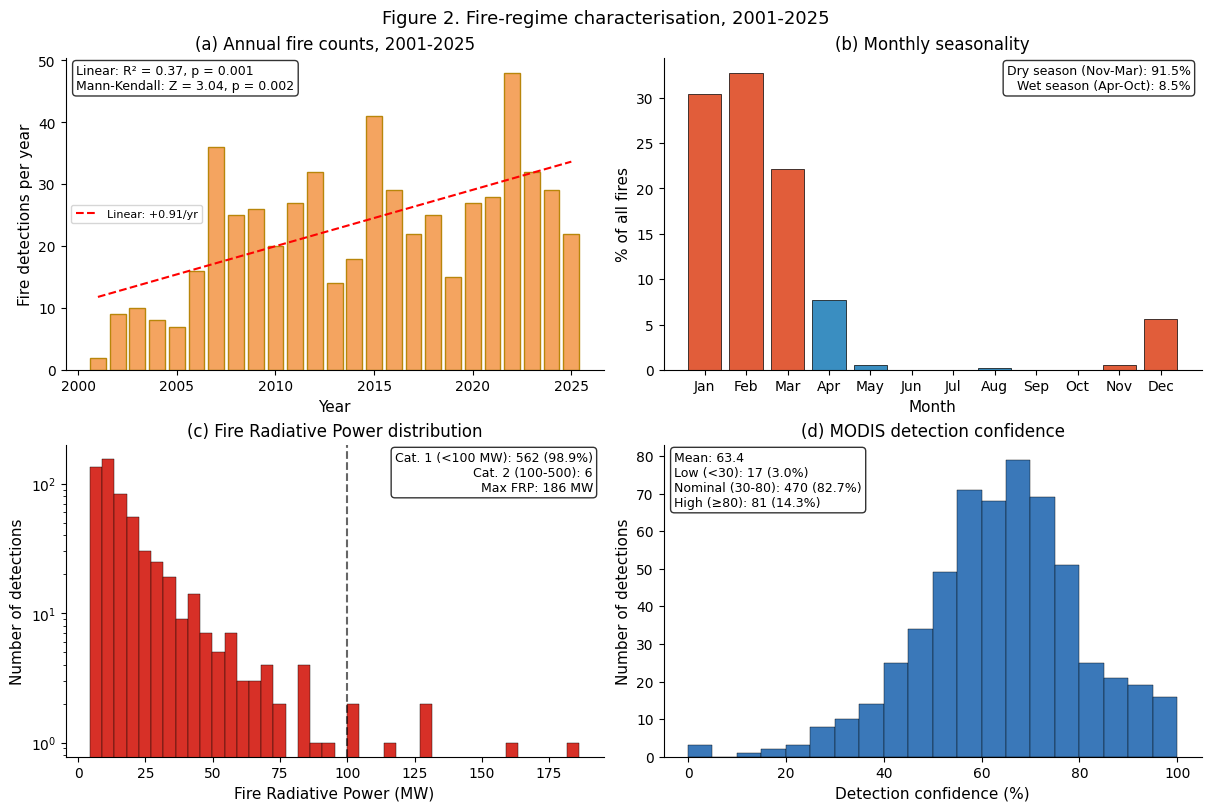

In [8]:

# ── Figure 2: four-panel fire-regime characterisation ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Panel (a): annual counts with linear trend
ax = axes[0, 0]
ax.bar(annual.index, annual.values, color="#f4a460", edgecolor="#b8860b")
xx = np.linspace(2001, 2025, 100)
ax.plot(xx, intercept + slope * xx, "r--", label=f"Linear: {slope:+.2f}/yr")
ax.set_xlabel("Year"); ax.set_ylabel("Fire detections per year")
ax.set_title("(a) Annual fire counts, 2001-2025")
ax.text(0.02, 0.98, f"Linear: R² = {r**2:.2f}, p = {p_lin:.3f}\n"
        f"Mann-Kendall: Z = {mk['Z']:.2f}, p = {mk['p']:.3f}",
        transform=ax.transAxes, va="top", ha="left", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax.legend(loc="center left", fontsize=8)

# Panel (b): monthly seasonality
ax = axes[0, 1]
monthly = fires_utm.groupby("month").size().reindex(range(1, 13), fill_value=0)
pct = 100 * monthly / monthly.sum()
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
colours = ["#e15d3a" if m in (11,12,1,2,3) else "#3a8ec1" for m in range(1, 13)]
ax.bar(months, pct.values, color=colours, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Month"); ax.set_ylabel("% of all fires")
ax.set_title("(b) Monthly seasonality")
ax.text(0.98, 0.98, f"Dry season (Nov-Mar): {100*n_dry/len(fires_utm):.1f}%\n"
        f"Wet season (Apr-Oct): {100*n_wet/len(fires_utm):.1f}%",
        transform=ax.transAxes, va="top", ha="right", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Panel (c): FRP distribution (log-y)
ax = axes[1, 0]
ax.hist(frp, bins=40, color="#d73027", edgecolor="black", linewidth=0.3)
ax.set_yscale("log")
ax.axvline(100, color="black", linestyle="--", alpha=0.6)
ax.set_xlabel("Fire Radiative Power (MW)"); ax.set_ylabel("Number of detections")
ax.set_title("(c) Fire Radiative Power distribution")
ax.text(0.98, 0.98,
    f"Cat. 1 (<100 MW): {int((frp<100).sum())} ({100*(frp<100).mean():.1f}%)\n"
    f"Cat. 2 (100-500): {int(((frp>=100)&(frp<500)).sum())}\n"
    f"Max FRP: {frp.max():.0f} MW",
    transform=ax.transAxes, va="top", ha="right", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Panel (d): MODIS detection confidence
ax = axes[1, 1]
ax.hist(conf, bins=20, color="#3a78b9", edgecolor="black", linewidth=0.3)
ax.set_xlabel("Detection confidence (%)"); ax.set_ylabel("Number of detections")
ax.set_title("(d) MODIS detection confidence")
n_low  = int((conf < 30).sum())
n_nom  = int(((conf >= 30) & (conf < 80)).sum())
n_high = int((conf >= 80).sum())
ax.text(0.02, 0.98,
    f"Mean: {conf.mean():.1f}\n"
    f"Low (<30): {n_low} ({100*n_low/len(conf):.1f}%)\n"
    f"Nominal (30-80): {n_nom} ({100*n_nom/len(conf):.1f}%)\n"
    f"High (≥80): {n_high} ({100*n_high/len(conf):.1f}%)",
    transform=ax.transAxes, va="top", ha="left", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

fig.suptitle("Figure 2. Fire-regime characterisation, 2001-2025", fontsize=13)
fig.savefig(os.path.join(OUT_DIR, "figures", "fig2_fire_regime.png"), dpi=200, bbox_inches="tight")
plt.show()



## 7. Climate-fire temporal coupling (Table 3 and Figure 3)

The annual climate aggregates are loaded from `Climatic_data.xlsx`, which
contains four columns (Year, Precipitation, Relative Humidity, Surface
Temperature) covering 2000-2025.

Three quasi-Poisson regression models are fitted using `statsmodels`. The
quasi-Poisson family is implemented as the Poisson family with `cov_type='HC0'`-
adjusted standard errors scaled by the Pearson dispersion. The dispersion
estimate is reported alongside each model.


In [9]:

# ── Load climate data ───────────────────────────────────────────────────────
clim = pd.read_excel(os.path.join(DATA_ROOT, "Climatic_data.xlsx"))
clim.columns = ["year", "precip", "rh", "temp"]
clim = clim.sort_values("year").reset_index(drop=True)

# ── Climate trend tests on the full series (2000-2025) ─────────────────────
print("Climate trends, 2000-2025:")
for var in ["precip", "rh", "temp"]:
    x = clim.year.values.astype(float); y = clim[var].values.astype(float)
    slope_, intc_, r_, p_, _ = stats.linregress(x, y)
    mk_ = mann_kendall(y)
    print(f"  {var:8s}: slope={slope_:+8.4f}/yr, R²={r_**2:.3f}, p_lin={p_:.4f}, "
          f"MK Z={mk_['Z']:+.2f}, p_MK={mk_['p']:.4f}")


Climate trends, 2000-2025:
  precip  : slope=+21.2764/yr, R²=0.239, p_lin=0.0113, MK Z=+2.42, p_MK=0.0153
  rh      : slope= +0.0614/yr, R²=0.169, p_lin=0.0371, MK Z=+1.41, p_MK=0.1583
  temp    : slope= +0.0122/yr, R²=0.139, p_lin=0.0605, MK Z=+2.01, p_MK=0.0449


In [10]:
# ── Quasi-Poisson regressions ──────────────────────────────────────────────
# Build per-year fire counts and merge with climate
ann_df = pd.DataFrame({"year": annual.index, "fires": annual.values})
ann_df = ann_df.merge(clim, on="year", how="left")
ann_df["precip_lag1"] = ann_df["precip"].shift(1)

# Models 1 and 2 use 25 years (2001-2025); Model 3 uses 24 years (2002-2025)
df12 = ann_df.dropna(subset=["precip", "rh", "temp"]).copy()
df3  = ann_df.dropna(subset=["precip", "precip_lag1", "temp"]).copy()
for d in (df12, df3):
    for v in ["precip", "rh", "temp"]:
        d[f"{v}_z"] = (d[v] - d[v].mean()) / d[v].std(ddof=0)
df3["precip_lag1_z"] = (df3.precip_lag1 - df3.precip_lag1.mean()) / df3.precip_lag1.std(ddof=0)

def fit_qp(formula, df_use):
    """Fit quasi-Poisson via statsmodels GLM with the Poisson family,
    then scale the standard errors by sqrt(phi) where phi is the Pearson
    dispersion. Return a tidy summary dataframe and the dispersion."""
    m = sm.GLM.from_formula(formula, data=df_use, family=sm.families.Poisson()).fit()
    pearson_chi2 = float(((m.resid_response) ** 2 / m.fittedvalues).sum())
    df_resid = m.df_resid
    phi = pearson_chi2 / df_resid

    # All the per-coefficient quantities below are pandas Series indexed by
    # predictor name. We use np.asarray() on each to coerce uniformly to
    # ndarray, sidestepping the differences that arise depending on whether
    # an arithmetic op returned a Series or a bare ndarray.
    beta   = np.asarray(m.params)
    se_qp  = np.asarray(m.bse * np.sqrt(phi))
    t      = beta / se_qp
    crit   = stats.t.ppf(0.975, df=df_resid)
    irr    = np.exp(beta)
    irr_lo = np.exp(beta - crit * se_qp)
    irr_hi = np.exp(beta + crit * se_qp)
    p      = 2 * (1 - stats.t.cdf(np.abs(t), df=df_resid))

    out = pd.DataFrame({
        "predictor": list(m.params.index),
        "beta":   beta,
        "SE_qp":  se_qp,
        "t":      t,
        "p":      p,
        "IRR":    irr,
        "IRR_lo": irr_lo,
        "IRR_hi": irr_hi,
    })
    return out, phi, df_resid, m

m1, phi1, df1, _   = fit_qp("fires ~ precip_z",                              df12)
m2, phi2, df2, _   = fit_qp("fires ~ precip_z + rh_z + temp_z",              df12)
m3, phi3, df3_n, _ = fit_qp("fires ~ precip_z + precip_lag1_z + temp_z",     df3)

print(f"Model 1: precip alone           — n = {len(df12)}, phi = {phi1:.3f}")
print(f"Model 2: precip + RH + temp     — n = {len(df12)}, phi = {phi2:.3f}")
print(f"Model 3: precip + lag1 + temp   — n = {len(df3)}, phi = {phi3:.3f}")

Model 1: precip alone           — n = 25, phi = 5.153
Model 2: precip + RH + temp     — n = 25, phi = 4.940
Model 3: precip + lag1 + temp   — n = 24, phi = 3.722


In [11]:

# ── Combined Table 3 ────────────────────────────────────────────────────────
def label_block(df_, label):
    out = df_.copy(); out.insert(0, "Model", label); return out
table3 = pd.concat([
    label_block(m1, "1. precip only"),
    label_block(m2, "2. precip + RH + temp"),
    label_block(m3, "3. precip + lag1 + temp"),
], ignore_index=True)
for c in ["beta", "SE_qp", "t", "IRR", "IRR_lo", "IRR_hi"]:
    table3[c] = table3[c].round(4)
table3["p"] = table3["p"].round(4)
table3.to_csv(os.path.join(OUT_DIR, "tables", "table3_quasipoisson.csv"), index=False)
table3


,Model,predictor,beta,SE_qp,t,p,IRR,IRR_lo,IRR_hi
0,1. precip only,Intercept,3.1054,0.0969,32.0390,0.0000,22.3189,18.2639,27.2742
1,1. precip only,precip_z,0.1883,0.0949,1.9833,0.0594,1.2072,0.9919,1.4692
2,2. precip + RH + temp,Intercept,3.0951,0.0959,32.2672,0.0000,22.0899,18.0951,26.9667
3,2. precip + RH + temp,precip_z,0.2324,0.1107,2.0998,0.0480,1.2616,1.0022,1.5881
4,2. precip + RH + temp,rh_z,-0.0794,0.1125,-0.7059,0.4880,0.9236,0.7309,1.1672
5,2. precip + RH + temp,temp_z,-0.1265,0.0920,-1.3758,0.1834,0.8811,0.7277,1.0669
6,3. precip + lag1 + temp,Intercept,3.1292,0.0837,37.3901,0.0000,22.8551,19.1940,27.2145
7,3. precip + lag1 + temp,precip_z,0.1404,0.0828,1.6970,0.1052,1.1508,0.9683,1.3676
8,3. precip + lag1 + temp,precip_lag1_z,0.1692,0.0854,1.9816,0.0614,1.1843,0.9911,1.4152
9,3. precip + lag1 + temp,temp_z,-0.0701,0.0817,-0.8575,0.4013,0.9323,0.7862,1.1056


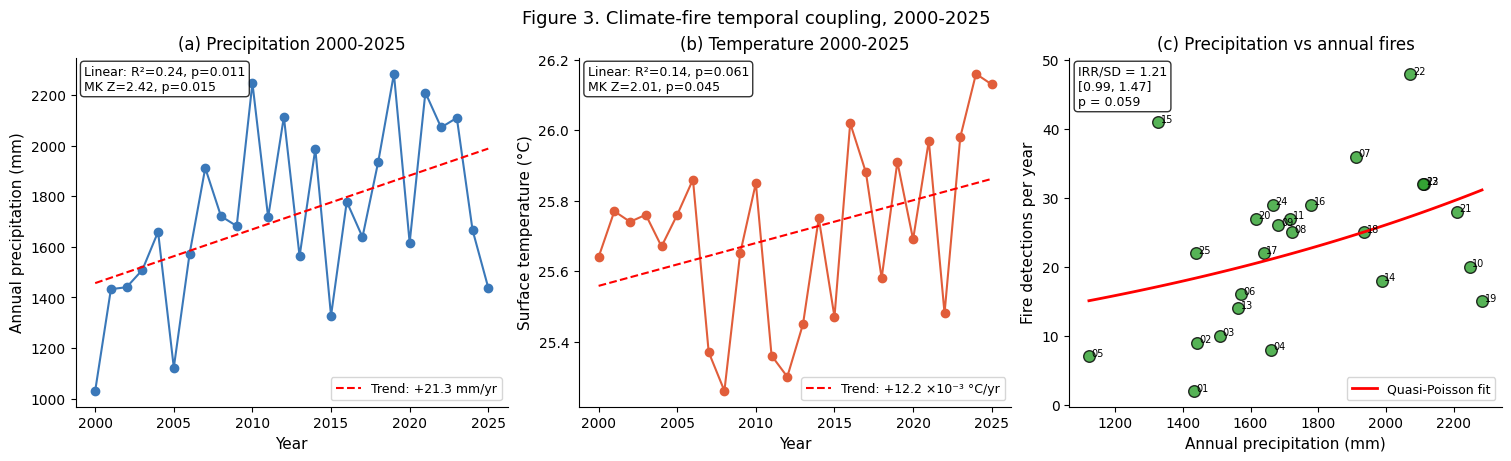

In [12]:

# ── Figure 3: climate trends and precip-fire scatter ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

# (a) Annual precipitation trend
ax = axes[0]
ax.plot(clim.year, clim.precip, "o-", color="#3a78b9")
xx = np.array(clim.year, dtype=float)
slope_p, intc_p, r_p, p_p, _ = stats.linregress(xx, clim.precip)
ax.plot(xx, intc_p + slope_p * xx, "r--", label=f"Trend: {slope_p:+.1f} mm/yr")
mk_p = mann_kendall(clim.precip.values)
ax.set_xlabel("Year"); ax.set_ylabel("Annual precipitation (mm)")
ax.set_title("(a) Precipitation 2000-2025")
ax.text(0.02, 0.98,
    f"Linear: R²={r_p**2:.2f}, p={p_p:.3f}\nMK Z={mk_p['Z']:.2f}, p={mk_p['p']:.3f}",
    transform=ax.transAxes, va="top", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax.legend(loc="lower right", fontsize=9)

# (b) Annual surface temperature trend
ax = axes[1]
ax.plot(clim.year, clim.temp, "o-", color="#e15d3a")
slope_t, intc_t, r_t, p_t, _ = stats.linregress(xx, clim.temp)
ax.plot(xx, intc_t + slope_t * xx, "r--", label=f"Trend: {slope_t*1000:+.1f} ×10⁻³ °C/yr")
mk_t = mann_kendall(clim.temp.values)
ax.set_xlabel("Year"); ax.set_ylabel("Surface temperature (°C)")
ax.set_title("(b) Temperature 2000-2025")
ax.text(0.02, 0.98,
    f"Linear: R²={r_t**2:.2f}, p={p_t:.3f}\nMK Z={mk_t['Z']:.2f}, p={mk_t['p']:.3f}",
    transform=ax.transAxes, va="top", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax.legend(loc="lower right", fontsize=9)

# (c) Precip-fire scatter with quasi-Poisson fit
ax = axes[2]
ax.scatter(df12.precip, df12.fires, c="#2ca02c", s=70, edgecolor="black", alpha=0.8)
for _, r_ in df12.iterrows():
    ax.text(r_.precip + 8, r_.fires, str(int(r_.year))[2:], fontsize=7)
xs = np.linspace(df12.precip.min(), df12.precip.max(), 100)
xs_z = (xs - df12.precip.mean()) / df12.precip.std(ddof=0)
beta_int, beta_p = m1.beta.iloc[0], m1.beta.iloc[1]
ys = np.exp(beta_int + beta_p * xs_z)
ax.plot(xs, ys, "r-", linewidth=2, label="Quasi-Poisson fit")
irr1 = m1.IRR.iloc[1]; irr1_lo = m1.IRR_lo.iloc[1]; irr1_hi = m1.IRR_hi.iloc[1]
p1 = m1.p.iloc[1]
ax.text(0.02, 0.98,
    f"IRR/SD = {irr1:.2f}\n[{irr1_lo:.2f}, {irr1_hi:.2f}]\np = {p1:.3f}",
    transform=ax.transAxes, va="top", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax.set_xlabel("Annual precipitation (mm)"); ax.set_ylabel("Fire detections per year")
ax.set_title("(c) Precipitation vs annual fires")
ax.legend(loc="lower right", fontsize=9)

fig.suptitle("Figure 3. Climate-fire temporal coupling, 2000-2025", fontsize=13)
fig.savefig(os.path.join(OUT_DIR, "figures", "fig3_climate_fire.png"), dpi=200, bbox_inches="tight")
plt.show()



## 8. Climate-raster pixel-distribution diagnostic (Figure 5)

This diagnostic exposes the silent uninformativeness of resampled
coarse-resolution NASA POWER data at single-reserve scale. The cell below
plots three of the climate criterion rasters (Humidity 2005, Precipitation
2015, Humidity 2025) alongside their pixel-value frequency distributions.


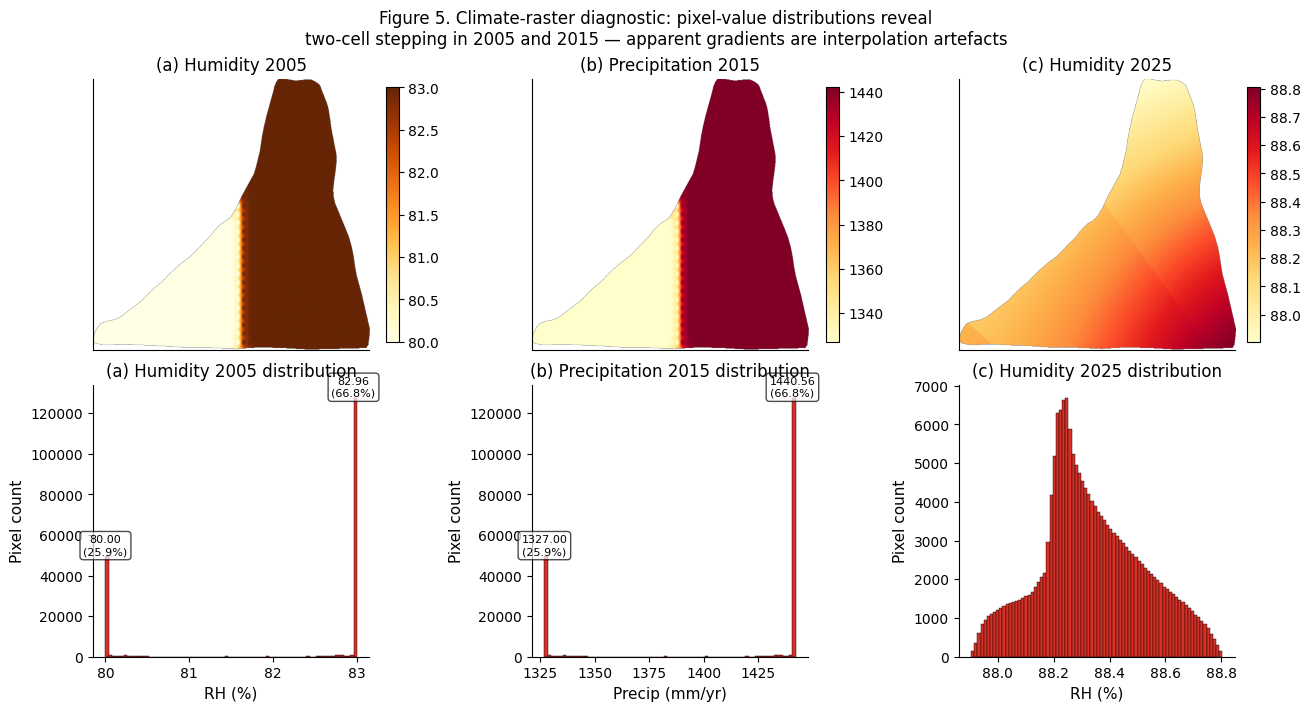

In [13]:

fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)

panels = [
    ("Humidity 2005",    "Humidity_2005",      "RH (%)",     "YlOrBr"),
    ("Precipitation 2015", "Precipitation_2015", "Precip (mm/yr)", "YlOrRd"),
    ("Humidity 2025",    "Humidity_2025",      "RH (%)",     "YlOrRd"),
]

for j, (title, layer_key, xlabel, cmap) in enumerate(panels):
    arr, transform, _, _ = load_raster(LAYER_PATHS[layer_key])
    valid = np.isfinite(arr)

    # Top: raster
    ax = axes[0, j]
    extent = (transform[2],
              transform[2] + arr.shape[1] * transform[0],
              transform[5] + arr.shape[0] * transform[4],
              transform[5])
    im = ax.imshow(arr, cmap=cmap, extent=extent, aspect="auto")
    ax.set_title(f"({chr(97 + j)}) {title}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Bottom: pixel-value histogram
    ax = axes[1, j]
    vals = arr[valid]
    ax.hist(vals, bins=80, color="#d73027", edgecolor="black", linewidth=0.3)
    ax.set_xlabel(xlabel); ax.set_ylabel("Pixel count")
    ax.set_title(f"({chr(97 + j)}) {title} distribution")
    # Annotate the two dominant values, if the histogram has clear modes
    counts, edges = np.histogram(vals, bins=80)
    top = np.argsort(counts)[-2:]
    for t in top:
        if counts[t] / len(vals) > 0.05:
            ax.text(edges[t], counts[t],
                    f"{edges[t]:.2f}\n({100*counts[t]/len(vals):.1f}%)",
                    fontsize=8, ha="center", va="bottom",
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

fig.suptitle(
    "Figure 5. Climate-raster diagnostic: pixel-value distributions reveal\n"
    "two-cell stepping in 2005 and 2015 — apparent gradients are interpolation artefacts",
    fontsize=12)
fig.savefig(os.path.join(OUT_DIR, "figures", "fig5_climate_diagnostic.png"),
            dpi=200, bbox_inches="tight")
plt.show()



## 9. AHP map and validation (Table 4 and Figure 4)

The AHP raster is loaded and validated against the fire detections. The
manuscript's Table 4 (criterion eigenvector weights) is hard-coded here from
the original pairwise comparison matrix.


In [14]:

# Table 4 — eigenvector weights from the original pairwise comparison
table4 = pd.DataFrame([
    ("Humidity",                30.86),
    ("Temperature",             18.74),
    ("Vegetation cover (NDVI)", 11.83),
    ("Distance to roads",        8.99),
    ("Slope",                    7.33),
    ("Distance to settlements",  5.50),
    ("Aspect",                   4.34),
    ("Elevation",                3.42),
    ("Precipitation",            6.04),
    ("Distance to water bodies", 2.95),
], columns=["AHP criterion", "Eigenvector weight (%)"])
table4["Eigenvector weight (%)"] = table4["Eigenvector weight (%)"].round(2)
table4.to_csv(os.path.join(OUT_DIR, "tables", "table4_ahp_weights.csv"), index=False)
table4


,AHP criterion,Eigenvector weight (%)
0,Humidity,30.86
1,Temperature,18.74
2,Vegetation cover (NDVI),11.83
3,Distance to roads,8.99
4,Slope,7.33
5,Distance to settlements,5.50
6,Aspect,4.34
7,Elevation,3.42
8,Precipitation,6.04
9,Distance to water bodies,2.95


In [15]:

# ── AHP validation ──────────────────────────────────────────────────────────
ahp_arr, ahp_t, ahp_crs, ahp_nd = load_raster(AHP_RASTER_PATH)
in_res = np.isfinite(ahp_arr) & (ahp_arr > 0)

# Sample AHP at fire locations
fires_utm["AHP_class"] = sample_raster(AHP_RASTER_PATH, fire_xs, fire_ys)
fires_utm["AHP_class"] = fires_utm["AHP_class"].where(
    fires_utm["AHP_class"].between(1, 3))

ahp_val = validate_classes(ahp_arr, fires_utm["AHP_class"].values, in_res)
print(f"AHP validation against {ahp_val['n_fires']} mapped fires:")
for c in (1, 2, 3):
    print(f"  Class {c}: area = {ahp_val['pct_area'][c]:5.2f}%, "
          f"fires = {ahp_val['pct_fire'][c]:5.2f}%, "
          f"lift = {ahp_val['lift'][c]:.2f}")
print(f"  AUC   = {ahp_val['auc']:.3f}  CI = [{ahp_val['auc_ci'][0]:.3f}, {ahp_val['auc_ci'][1]:.3f}]")
print(f"  χ²    = {ahp_val['chi2']:.2f}, p = {ahp_val['chi2_p']:.4f}")


AHP validation against 560 mapped fires:
  Class 1: area =  0.69%, fires =  0.71%, lift = 1.04
  Class 2: area = 80.16%, fires = 86.96%, lift = 1.08
  Class 3: area = 19.15%, fires = 12.32%, lift = 0.64
  AUC   = 0.464  CI = [0.438, 0.489]
  χ²    = 16.87, p = 0.0002


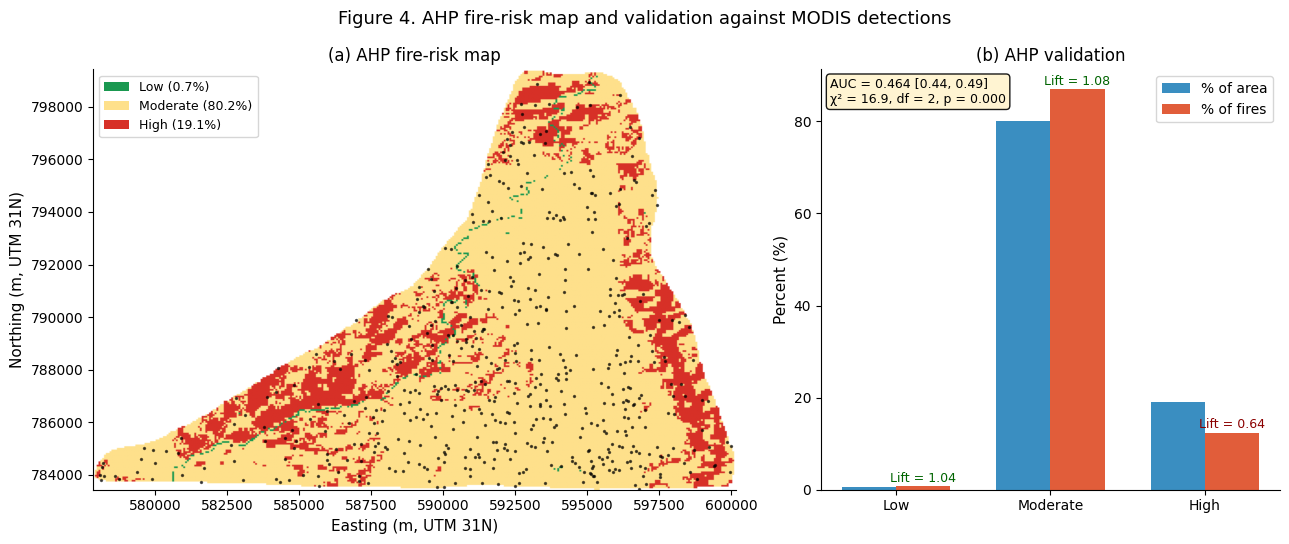

In [16]:

# ── Figure 4: AHP risk surface and validation bars ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5),
                          gridspec_kw={"width_ratios": [1.4, 1]})

# (a) AHP map with fires overlaid
ax = axes[0]
extent = (ahp_t[2], ahp_t[2] + ahp_arr.shape[1] * ahp_t[0],
          ahp_t[5] + ahp_arr.shape[0] * ahp_t[4], ahp_t[5])
display = np.where(np.isfinite(ahp_arr), ahp_arr, 0)
cmap = mcolors.ListedColormap(["white", "#1a9850", "#fee08b", "#d73027"])
norm = mcolors.BoundaryNorm([0, 0.5, 1.5, 2.5, 3.5], cmap.N)
im = ax.imshow(display, cmap=cmap, norm=norm, extent=extent, aspect="auto")
ax.scatter(fire_xs, fire_ys, s=2, c="black", alpha=0.6,
            label=f"Fires (n = {int(ahp_val['n_fires'])})")
ax.set_xlabel("Easting (m, UTM 31N)"); ax.set_ylabel("Northing (m, UTM 31N)")
ax.set_title("(a) AHP fire-risk map")
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc="#1a9850",
                  label=f"Low ({ahp_val['pct_area'][1]:.1f}%)"),
    plt.Rectangle((0, 0), 1, 1, fc="#fee08b",
                  label=f"Moderate ({ahp_val['pct_area'][2]:.1f}%)"),
    plt.Rectangle((0, 0), 1, 1, fc="#d73027",
                  label=f"High ({ahp_val['pct_area'][3]:.1f}%)"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)

# (b) Lift validation
ax = axes[1]
classes = ["Low", "Moderate", "High"]
x = np.arange(3); w = 0.35
area_pct = [ahp_val["pct_area"][c] for c in (1, 2, 3)]
fire_pct = [ahp_val["pct_fire"][c] for c in (1, 2, 3)]
ax.bar(x - w/2, area_pct, w, label="% of area", color="#3a8ec1")
ax.bar(x + w/2, fire_pct, w, label="% of fires", color="#e15d3a")
for c, xi in zip((1, 2, 3), x):
    ax.text(xi + w/2, fire_pct[c-1] + 1,
            f"Lift = {ahp_val['lift'][c]:.2f}", ha="center", fontsize=9,
            color="darkred" if ahp_val['lift'][c] < 1 else "darkgreen")
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel("Percent (%)"); ax.set_title("(b) AHP validation")
ax.legend()
ax.text(0.02, 0.98,
    f"AUC = {ahp_val['auc']:.3f} [{ahp_val['auc_ci'][0]:.2f}, {ahp_val['auc_ci'][1]:.2f}]\n"
    f"χ² = {ahp_val['chi2']:.1f}, df = 2, p = {ahp_val['chi2_p']:.3f}",
    transform=ax.transAxes, va="top", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="#fff3cd", alpha=0.9))

fig.suptitle("Figure 4. AHP fire-risk map and validation against MODIS detections",
             fontsize=13)
fig.savefig(os.path.join(OUT_DIR, "figures", "fig4_ahp_validation.png"),
            dpi=200, bbox_inches="tight")
plt.tight_layout()
plt.show()



## 10. Pseudo-absence generation

The data-driven models require pseudo-absences — locations sampled from the
within-reserve background. The `gen_absences` function below samples
uniformly from the in-reserve LULC pixels (non-NaN). An optional spatial
exclusion radius removes candidate cells within the given distance of any
fire point. The radius defaults to zero (matching the manuscript's baseline
protocol); the sensitivity analysis later in the notebook (§13) varies it.


In [17]:

# Load LULC array and its transform once
lulc_arr, lulc_t, lulc_crs, lulc_nd = load_raster(LAYER_PATHS["LULC"])

def gen_absences(n_target, exclusion_radius=0.0, fire_xy=None, seed=RANDOM_SEED):
    """Sample pseudo-absences from in-reserve LULC pixels.

    Parameters
    ----------
    n_target          : desired number of absences
    exclusion_radius  : radius (in metres) within which candidate cells are
                        removed if they fall too close to any fire point.
                        Pass 0 to disable the exclusion (baseline protocol).
    fire_xy           : optional Nx2 array of fire UTM coordinates.  Required
                        if exclusion_radius > 0.
    seed              : RNG seed for reproducibility.

    Returns
    -------
    Two arrays (xs, ys) of UTM coordinates, length n_target.
    """
    valid_rc = np.where(np.isfinite(lulc_arr))
    rows, cols = valid_rc
    # Pixel centre coordinates
    xs = lulc_t[2] + (cols + 0.5) * lulc_t[0]
    ys = lulc_t[5] + (rows + 0.5) * lulc_t[4]

    if exclusion_radius > 0 and fire_xy is not None:
        # Vectorised distance check using a KD-tree on fires
        ftree = cKDTree(fire_xy)
        nearest_dist = ftree.query(np.column_stack([xs, ys]), k=1)[0]
        keep = nearest_dist > exclusion_radius
        xs, ys = xs[keep], ys[keep]

    if len(xs) < n_target:
        n_target = len(xs)
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(xs), size=n_target, replace=False)
    return xs[idx], ys[idx]

# Quick sanity test
ax_test, ay_test = gen_absences(100)
print(f"Sample of 100 absences generated, x range "
      f"[{ax_test.min():.0f}, {ax_test.max():.0f}]")


Sample of 100 absences generated, x range [578281, 599671]



## 11. Building the data-driven feature matrix

A single function `build_dataset` returns a clean dataframe of presences and
absences with all 12 continuous predictors (NDVI×3, LST×3, terrain×3,
distance×3) and the LULC categorical, ready for any of the four model classes.
The function is called once for the baseline and is reused later for the
pseudo-absence sensitivity grid and the high-confidence-only re-analysis.


In [18]:

CONT_PRED = ["NDVI_2025", "NDVI_2015", "NDVI_2005",
             "LST_2025",  "LST_2015",  "LST_2005",
             "Slope",     "Aspect",    "Elev",
             "D2Place",   "D2Road",    "D2Water"]
LOG_DIST = ["D2Place", "D2Road", "D2Water"]
LULC_OUTSIDE = 15  # nodata code in the LULC raster

def build_dataset(fires_df, ratio=5, exclusion_radius=0.0, seed=RANDOM_SEED):
    """Return a clean presence/absence dataframe with 12 continuous
    predictors and the LULC categorical, suitable for fitting any of the four
    model classes.

    The function (1) generates pseudo-absences with the given ratio and
    optional spatial exclusion; (2) samples every predictor at every point;
    (3) drops rows with missing values in any continuous predictor or with
    zero distance values."""
    fire_xy = fires_df[["x_utm", "y_utm"]].values
    abs_x, abs_y = gen_absences(ratio * len(fires_df), exclusion_radius, fire_xy, seed)

    # Sample predictors at absence points
    abs_df = pd.DataFrame({"x_utm": abs_x, "y_utm": abs_y, "fire": 0})
    for k in CONT_PRED + ["LULC"]:
        abs_df[k] = sample_raster(LAYER_PATHS[k], abs_x, abs_y)

    # Bind presences (already sampled in §5) with absences
    pres_df = fires_df[["x_utm", "y_utm"] + CONT_PRED + ["LULC"]].copy()
    pres_df["fire"] = 1
    df = pd.concat([pres_df, abs_df], ignore_index=True)

    # Clean: keep only in-reserve, non-missing rows
    df = df[df.LULC.notna() & (df.LULC != LULC_OUTSIDE)].copy()
    df = df.dropna(subset=CONT_PRED)
    df = df[(df.D2Place > 0) & (df.D2Road > 0) & (df.D2Water > 0)]
    return df.reset_index(drop=True)

def features_from_df(df):
    """Apply log transforms, z-scoring, and one-hot encoding.  Return
    (X, y, feature_names).  This pre-processing is identical to what was
    used in the manuscript."""
    df = df.copy()
    for c in LOG_DIST:
        df[c] = np.log1p(df[c])
    X_cont = StandardScaler().fit_transform(df[CONT_PRED])
    X_cat = pd.get_dummies(df[["LULC"]].astype(int).astype(str), drop_first=True)
    X = np.column_stack([X_cont, X_cat.values.astype(float)])
    feat_names = CONT_PRED + list(X_cat.columns)
    y = df["fire"].values.astype(int)
    return X, y, feat_names, df

# ── Baseline dataset (5:1 ratio, no exclusion) ──────────────────────────────
df_base = build_dataset(fires_utm, ratio=5, exclusion_radius=0)
print(f"Baseline dataset: n = {len(df_base)} "
      f"(fires = {df_base.fire.sum()}, abs = {(df_base.fire == 0).sum()})")
df_base.to_csv(os.path.join(OUT_DIR, "tables", "df_baseline.csv"), index=False)


Baseline dataset: n = 3123 (fires = 538, abs = 2585)



## 12. Data-driven model comparison (Table 6 and Figure 7)

The four model classes (logistic regression, random forest, gradient boosting,
MaxEnt-style L1 logistic regression with hinge features) are fitted on the
baseline 5:1 dataset. For each model we report in-sample AUC, random k-fold
CV AUC (5×3), and 5×5 spatial-block CV AUC.

The MaxEnt implementation here is L1-penalised logistic regression with
manually constructed hinge basis features; this reproduces the
feature-engineering principle of the Maxnet R package without relying on R.


In [19]:

# ── Hinge-feature construction for the MaxEnt model ────────────────────────
def make_hinge_features(X, n_knots=4):
    """Construct linear, quadratic, and four-knot hinge features for each
    column of X.  Returns a wider matrix with derived features appended."""
    feats = [X, X ** 2]
    for j in range(X.shape[1]):
        knots = np.quantile(X[:, j], np.linspace(0.1, 0.9, n_knots))
        for k in knots:
            feats.append(np.maximum(0, X[:, j] - k).reshape(-1, 1))   # upper hinge
            feats.append(np.maximum(0, k - X[:, j]).reshape(-1, 1))   # lower hinge
    return np.column_stack(feats)

# ── Spatial blocks for 5×5 spatial-block CV ─────────────────────────────────
def assign_blocks(df, nx=5, ny=5, seed=RANDOM_SEED):
    """Assign each row to one of nx*ny spatial blocks, then random-shuffle
    those blocks into 5 folds for cross-validation."""
    bx = pd.cut(df.x_utm, bins=nx, labels=False)
    by = pd.cut(df.y_utm, bins=ny, labels=False)
    block = bx * ny + by
    unique = sorted(block.dropna().unique())
    rng = np.random.default_rng(seed)
    fold_blocks = [list(b) for b in np.array_split(rng.permutation(unique), 5)]
    return block.values, fold_blocks

def cv_auc(model_fn, X, y, n_seeds=3):
    """Random 5-fold cross-validated AUC, averaged over n_seeds seeds."""
    aucs = []
    for s in range(RANDOM_SEED, RANDOM_SEED + n_seeds):
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
        for tr, te in skf.split(X, y):
            m = model_fn(); m.fit(X[tr], y[tr])
            aucs.append(roc_auc_score(y[te], m.predict_proba(X[te])[:, 1]))
    return float(np.mean(aucs)), float(np.std(aucs))

def spat_cv_auc(model_fn, X, y, blocks, fold_blocks):
    """Spatial-block cross-validated AUC."""
    aucs = []
    for fb in fold_blocks:
        te = np.isin(blocks, fb); tr = ~te
        if y[tr].sum() < 10 or y[te].sum() < 5: continue
        m = model_fn(); m.fit(X[tr], y[tr])
        aucs.append(roc_auc_score(y[te], m.predict_proba(X[te])[:, 1]))
    return float(np.mean(aucs)), float(np.std(aucs))

# ── Build features ─────────────────────────────────────────────────────────
X_base, y_base, feat_names, df_log_base = features_from_df(df_base)
X_max = make_hinge_features(X_base[:, :len(CONT_PRED)])
X_max = np.column_stack([X_max, X_base[:, len(CONT_PRED):]])  # add LULC dummies
blocks_base, fold_blocks_base = assign_blocks(df_log_base)
print(f"Feature matrices: baseline {X_base.shape}, MaxEnt {X_max.shape}")


Feature matrices: baseline (3123, 16), MaxEnt (3123, 124)


In [20]:

# ── Fit four models and collect AUCs ────────────────────────────────────────
def lr(): return LogisticRegression(max_iter=5000, C=1.0, solver="lbfgs")
def rf(): return RandomForestClassifier(
    n_estimators=100, max_depth=6, min_samples_leaf=15,
    random_state=RANDOM_SEED, n_jobs=-1)
def gb(): return GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    min_samples_leaf=15, random_state=RANDOM_SEED)
def me(): return LogisticRegression(
    penalty="l1", solver="liblinear", C=0.5, max_iter=5000,
    class_weight="balanced", random_state=RANDOM_SEED)

models = [
    ("Logistic regression",       lr, X_base),
    ("Random Forest",             rf, X_base),
    ("Gradient Boosting",         gb, X_base),
    ("MaxEnt (Maxnet-style, L1)", me, X_max),
]

table6_rows = []
for name, fn, X in models:
    in_auc = roc_auc_score(y_base, fn().fit(X, y_base).predict_proba(X)[:, 1])
    rmean, rsd = cv_auc(fn, X, y_base, n_seeds=3)
    smean, ssd = spat_cv_auc(fn, X, y_base, blocks_base, fold_blocks_base)
    table6_rows.append({
        "Model": name,
        "In-sample AUC":      f"{in_auc:.3f}",
        "Random CV AUC":      f"{rmean:.3f} ± {rsd:.3f}",
        "Spatial-block CV AUC": f"{smean:.3f} ± {ssd:.3f}",
    })
    print(f"{name:32s} in={in_auc:.3f}  rand={rmean:.3f}±{rsd:.3f}  spat={smean:.3f}±{ssd:.3f}")

table6 = pd.DataFrame(table6_rows)
table6.to_csv(os.path.join(OUT_DIR, "tables", "table6_models.csv"), index=False)
table6


Logistic regression              in=0.612  rand=0.588±0.025  spat=0.581±0.050
Random Forest                    in=0.796  rand=0.586±0.026  spat=0.563±0.046
Gradient Boosting                in=0.791  rand=0.573±0.020  spat=0.548±0.037
MaxEnt (Maxnet-style, L1)        in=0.649  rand=0.589±0.027  spat=0.563±0.045


,Model,In-sample AUC,Random CV AUC,Spatial-block CV AUC
0,Logistic regression,0.612,0.588 ± 0.025,0.581 ± 0.050
1,Random Forest,0.796,0.586 ± 0.026,0.563 ± 0.046
2,Gradient Boosting,0.791,0.573 ± 0.020,0.548 ± 0.037
3,"MaxEnt (Maxnet-style, L1)",0.649,0.589 ± 0.027,0.563 ± 0.045


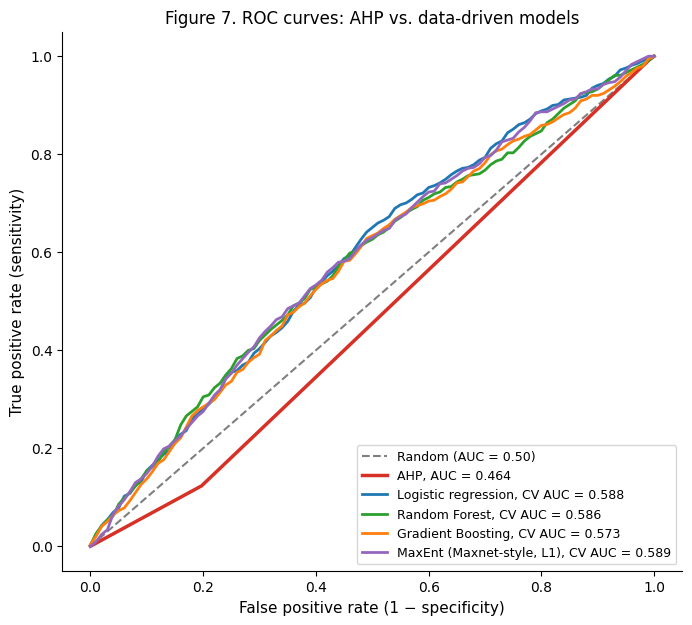

In [21]:

# ── Figure 7: ROC curves for the four models ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random (AUC = 0.50)")

# AHP ROC: use class label as score
ahp_class = fires_utm["AHP_class"].dropna().values
n_pres = len(ahp_class)
rng = np.random.default_rng(RANDOM_SEED)
rc = np.where(in_res); idx = rng.choice(len(rc[0]), size=5*n_pres, replace=False)
abs_classes = ahp_arr[rc[0][idx], rc[1][idx]]
y_ahp = np.concatenate([np.ones(n_pres), np.zeros(len(idx))])
s_ahp = np.concatenate([ahp_class, abs_classes])
fpr_a, tpr_a, _ = roc_curve(y_ahp, s_ahp)
ax.plot(fpr_a, tpr_a, color="#d73027", linewidth=2.5,
        label=f"AHP, AUC = {ahp_val['auc']:.3f}")

# Data-driven model ROC curves (cross-validated mean across folds)
colors = {"Logistic regression": "#1f77b4",
           "Random Forest":      "#2ca02c",
           "Gradient Boosting":  "#ff7f0e",
           "MaxEnt (Maxnet-style, L1)": "#9467bd"}
for name, fn, X in models:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    fprs, tprs = [], []
    base_fpr = np.linspace(0, 1, 101)
    for tr, te in skf.split(X, y_base):
        m = fn(); m.fit(X[tr], y_base[tr])
        fpr_, tpr_, _ = roc_curve(y_base[te], m.predict_proba(X[te])[:, 1])
        tprs.append(np.interp(base_fpr, fpr_, tpr_))
    mean_tpr = np.mean(tprs, axis=0)
    auc_v = next(float(r["Random CV AUC"].split()[0]) for r in table6_rows if r["Model"] == name)
    ax.plot(base_fpr, mean_tpr, color=colors[name], linewidth=2,
            label=f"{name}, CV AUC = {auc_v:.3f}")

ax.set_xlabel("False positive rate (1 − specificity)")
ax.set_ylabel("True positive rate (sensitivity)")
ax.set_title("Figure 7. ROC curves: AHP vs. data-driven models")
ax.legend(loc="lower right", fontsize=9)
fig.savefig(os.path.join(OUT_DIR, "figures", "fig7_roc_curves.png"),
            dpi=200, bbox_inches="tight")
plt.show()



## 13. Pseudo-absence sensitivity (Table S1 and Figure S1)

This is one of the principal new analyses introduced for the revision. The
logistic regression is refitted across a 3 × 4 grid of pseudo-absence design
configurations: ratios {1:1, 5:1, 10:1} × spatial exclusion radii {0, 250,
500, 1000 m}. The result reveals that AUC depends substantially on the
exclusion radius, and that the apparent 0.6 ceiling at zero exclusion is a
property of the absence design rather than of the predictors.


In [22]:

sens_rows = []
for ratio in [1, 5, 10]:
    for radius in [0, 250, 500, 1000]:
        df_s = build_dataset(fires_utm, ratio=ratio, exclusion_radius=radius)
        if df_s.fire.sum() < 50 or (df_s.fire == 0).sum() < 50:
            print(f"ratio={ratio}, radius={radius}: insufficient data, skipping.")
            continue
        X_s, y_s, _, df_log_s = features_from_df(df_s)
        in_auc = roc_auc_score(y_s, lr().fit(X_s, y_s).predict_proba(X_s)[:, 1])
        rmean, rsd = cv_auc(lr, X_s, y_s, n_seeds=3)
        try:
            blocks_s, fold_blocks_s = assign_blocks(df_log_s)
            smean, ssd = spat_cv_auc(lr, X_s, y_s, blocks_s, fold_blocks_s)
        except Exception:
            smean, ssd = float("nan"), float("nan")
        sens_rows.append({
            "ratio": ratio, "exclusion_m": radius,
            "n": len(df_s), "n_fires": int(y_s.sum()), "n_abs": int((y_s == 0).sum()),
            "auc_in":      in_auc,
            "auc_rand_cv": rmean, "auc_rand_sd": rsd,
            "auc_spat_cv": smean, "auc_spat_sd": ssd,
        })
        print(f"ratio={ratio}, radius={radius:4d}: n={len(df_s):4d}  "
              f"in={in_auc:.3f}  rand={rmean:.3f}±{rsd:.3f}  "
              f"spat={smean:.3f}±{ssd:.3f}")

table_s1 = pd.DataFrame(sens_rows)
table_s1.to_csv(os.path.join(OUT_DIR, "tables", "tableS1_pseudoabs_sensitivity.csv"),
                 index=False)
table_s1.round(3)


ratio=1, radius=   0: n=1055  in=0.616  rand=0.574±0.026  spat=0.589±0.036
ratio=1, radius= 250: n=1044  in=0.674  rand=0.647±0.030  spat=0.618±0.064
ratio=1, radius= 500: n=1016  in=0.814  rand=0.800±0.021  spat=0.720±0.073
ratio=1, radius=1000: n= 981  in=0.983  rand=0.981±0.006  spat=nan±nan
ratio=5, radius=   0: n=3123  in=0.612  rand=0.588±0.025  spat=0.581±0.050
ratio=5, radius= 250: n=3068  in=0.690  rand=0.674±0.028  spat=0.641±0.061
ratio=5, radius= 500: n=2954  in=0.805  rand=0.798±0.019  spat=0.701±0.080
ratio=5, radius=1000: n=1199  in=0.983  rand=0.981±0.005  spat=nan±nan
ratio=10, radius=   0: n=5649  in=0.628  rand=0.611±0.030  spat=0.607±0.047
ratio=10, radius= 250: n=5603  in=0.685  rand=0.672±0.026  spat=0.642±0.065
ratio=10, radius= 500: n=5330  in=0.804  rand=0.798±0.022  spat=0.708±0.067
ratio=10, radius=1000: n=1199  in=0.983  rand=0.981±0.005  spat=nan±nan


,ratio,exclusion_m,n,n_fires,n_abs,auc_in,auc_rand_cv,auc_rand_sd,auc_spat_cv,auc_spat_sd
0,1,0,1055,538,517,0.616,0.574,0.026,0.589,0.036
1,1,250,1044,538,506,0.674,0.647,0.030,0.618,0.064
2,1,500,1016,538,478,0.814,0.800,0.021,0.720,0.073
3,1,1000,981,538,443,0.983,0.981,0.006,NaN,NaN
4,5,0,3123,538,2585,0.612,0.588,0.025,0.581,0.050
5,5,250,3068,538,2530,0.690,0.674,0.028,0.641,0.061
6,5,500,2954,538,2416,0.805,0.798,0.019,0.701,0.080
7,5,1000,1199,538,661,0.983,0.981,0.005,NaN,NaN
8,10,0,5649,538,5111,0.628,0.611,0.030,0.607,0.047
9,10,250,5603,538,5065,0.685,0.672,0.026,0.642,0.065


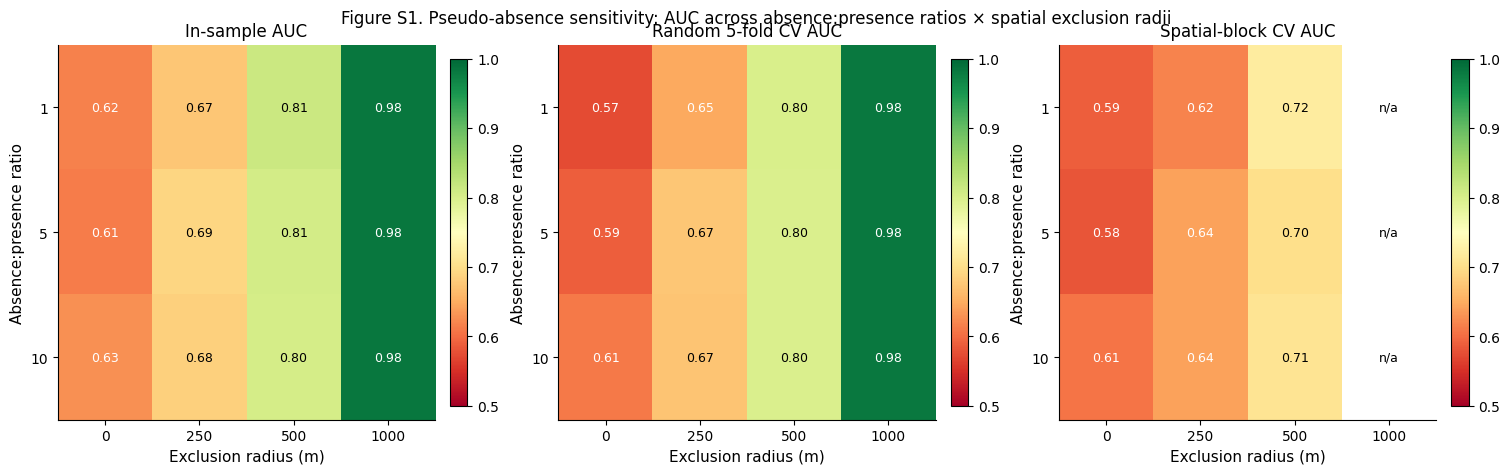

In [23]:

# ── Figure S1: pseudo-absence sensitivity heatmaps ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, metric, title in [
    (axes[0], "auc_in",     "In-sample AUC"),
    (axes[1], "auc_rand_cv","Random 5-fold CV AUC"),
    (axes[2], "auc_spat_cv","Spatial-block CV AUC"),
]:
    pivot = table_s1.pivot(index="ratio", columns="exclusion_m", values=metric)
    im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0.5, vmax=1.0, aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Exclusion radius (m)"); ax.set_ylabel("Absence:presence ratio")
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                col = "white" if v < 0.65 or v > 0.85 else "black"
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                         color=col, fontsize=9)
            else:
                ax.text(j, i, "n/a", ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Figure S1. Pseudo-absence sensitivity: AUC across "
             "absence:presence ratios × spatial exclusion radii",
             fontsize=12, y=1.02)
fig.savefig(os.path.join(OUT_DIR, "figures", "figS1_pseudoabs_sensitivity.png"),
            dpi=200, bbox_inches="tight")
plt.show()



## 14. Predictor correlation, VIF, and stratified analysis (Tables S2, S3 and Figures S3, S4)

These analyses address the reviewer's concern that distance variables might
be confounded with vegetation indices via shared spatial structure. The cell
below computes the predictor correlation matrix, the variance inflation
factors, and an interior-vs-edge stratified logistic regression.


In [24]:

# ── Predictor correlation matrix ────────────────────────────────────────────
corr = pd.DataFrame(X_base[:, :len(CONT_PRED)], columns=CONT_PRED).corr().round(3)
corr.to_csv(os.path.join(OUT_DIR, "tables", "tableS2a_correlation.csv"))

# ── Variance Inflation Factors ──────────────────────────────────────────────
X_with_int = sm.add_constant(X_base[:, :len(CONT_PRED)])
vifs = {CONT_PRED[i]: variance_inflation_factor(X_with_int, i + 1)
        for i in range(len(CONT_PRED))}
table_s2b = pd.DataFrame([{"Predictor": k, "VIF": round(v, 2)}
                           for k, v in vifs.items()])
table_s2b.to_csv(os.path.join(OUT_DIR, "tables", "tableS2b_vif.csv"), index=False)
table_s2b


,Predictor,VIF
0,NDVI_2025,2.99
1,NDVI_2015,3.69
2,NDVI_2005,3.56
3,LST_2025,3.32
4,LST_2015,2.71
5,LST_2005,2.86
6,Slope,1.15
7,Aspect,1.10
8,Elev,1.55
9,D2Place,1.31


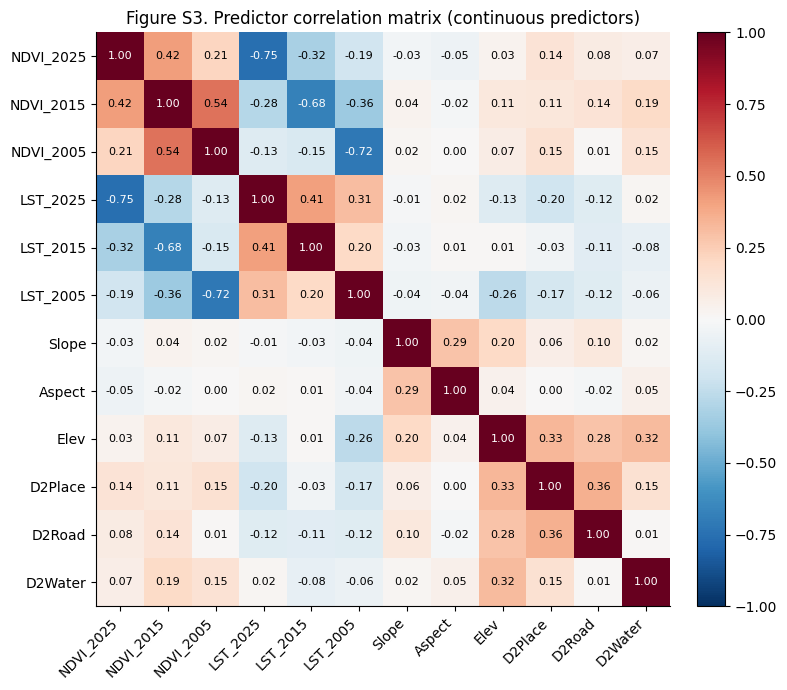

In [25]:

# ── Figure S3: predictor correlation heatmap ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                 color="white" if abs(v) > 0.6 else "black", fontsize=8)
plt.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Figure S3. Predictor correlation matrix (continuous predictors)")
fig.savefig(os.path.join(OUT_DIR, "figures", "figS3_correlation.png"),
            dpi=200, bbox_inches="tight")
plt.tight_layout()
plt.show()


In [26]:

# ── Stratified analysis: interior vs edge ──────────────────────────────────
median_d2r = df_base["D2Road"].median()
edge_mask  = df_base["D2Road"] <  median_d2r
int_mask   = df_base["D2Road"] >= median_d2r
print(f"D2Road median = {median_d2r:.0f} m")
print(f"Edge     n = {edge_mask.sum()} (fires = {df_base[edge_mask].fire.sum()})")
print(f"Interior n = {int_mask.sum()} (fires = {df_base[int_mask].fire.sum()})")

def fit_strat(sub):
    """Fit logistic regression on a subset; return tidy dataframe of ORs."""
    X_, y_, names, _ = features_from_df(sub)
    X_d = sm.add_constant(X_)
    m = sm.Logit(y_, X_d).fit(disp=0, maxiter=200)
    or_ = np.exp(m.params)
    or_lo = np.exp(m.params - 1.96 * m.bse)
    or_hi = np.exp(m.params + 1.96 * m.bse)
    out = pd.DataFrame({
        "predictor": ["Intercept"] + names,
        "OR":        or_,
        "OR_lo":     or_lo,
        "OR_hi":     or_hi,
        "p":         m.pvalues,
    })
    return out

strat_edge = fit_strat(df_base[edge_mask].reset_index(drop=True))
strat_int  = fit_strat(df_base[int_mask].reset_index(drop=True))
strat_edge["zone"] = "edge";     strat_int["zone"] = "interior"
table_s3 = pd.concat([strat_edge, strat_int], ignore_index=True)
table_s3.to_csv(os.path.join(OUT_DIR, "tables", "tableS3_stratified.csv"), index=False)
table_s3.round(3)


D2Road median = 1139 m
Edge     n = 1555 (fires = 219)
Interior n = 1568 (fires = 319)


,predictor,OR,OR_lo,OR_hi,p,zone
0,Intercept,0.153,0.127,0.184,0.000,edge
1,NDVI_2025,1.409,1.010,1.964,0.043,edge
2,NDVI_2015,1.081,0.818,1.430,0.584,edge
3,NDVI_2005,0.950,0.746,1.208,0.674,edge
4,LST_2025,1.313,1.005,1.715,0.046,edge
5,LST_2015,1.221,0.954,1.563,0.113,edge
6,LST_2005,0.900,0.723,1.122,0.350,edge
7,Slope,1.103,0.947,1.284,0.210,edge
8,Aspect,1.105,0.946,1.290,0.207,edge
9,Elev,1.049,0.886,1.243,0.577,edge


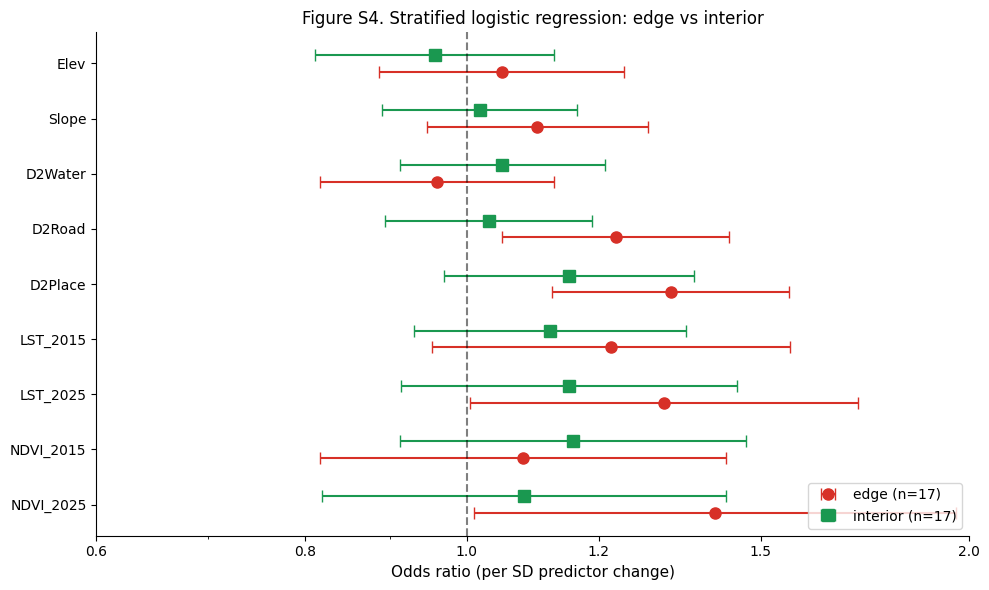

In [27]:

# ── Figure S4: stratified ORs side by side ─────────────────────────────────
keys = ["NDVI_2025", "NDVI_2015", "LST_2025", "LST_2015",
         "D2Place", "D2Road", "D2Water", "Slope", "Elev"]
fig, ax = plt.subplots(figsize=(10, 6))
for label, df_, marker, color, offset in [
    ("edge",     strat_edge, "o", "#d73027", -0.15),
    ("interior", strat_int,  "s", "#1a9850",  0.15),
]:
    sub = df_.set_index("predictor").loc[keys]
    y_pos = np.arange(len(keys)) + offset
    ax.errorbar(sub["OR"], y_pos,
                xerr=[sub["OR"] - sub["OR_lo"], sub["OR_hi"] - sub["OR"]],
                fmt=marker, color=color,
                label=f"{label} (n={int(df_.shape[0])})",
                markersize=8, capsize=4)
ax.axvline(1.0, color="black", linestyle="--", alpha=0.5)
ax.set_yticks(np.arange(len(keys))); ax.set_yticklabels(keys)
ax.set_xlabel("Odds ratio (per SD predictor change)")
ax.set_xscale("log")
ax.set_xlim(0.6, 2.0)
ax.set_xticks([0.6, 0.8, 1.0, 1.2, 1.5, 2.0])
ax.set_xticklabels(["0.6", "0.8", "1.0", "1.2", "1.5", "2.0"])
ax.legend(loc="lower right")
ax.set_title("Figure S4. Stratified logistic regression: edge vs interior")
fig.savefig(os.path.join(OUT_DIR, "figures", "figS4_stratified.png"),
            dpi=200, bbox_inches="tight")
plt.tight_layout()
plt.show()



## 15. High-confidence detection subset (Figure S5)

The data-driven model and AHP validation are repeated using only those MODIS
detections with confidence ≥ 80. The result strengthens the conclusion that
AHP fails most for the very fires it would be most important to flag.


In [28]:

fires_hc = fires_utm[fires_utm.CONFIDENCE >= 80].copy().reset_index(drop=True)
print(f"High-confidence fires (confidence ≥ 80): n = {len(fires_hc)}")

# Build dataset
df_hc = build_dataset(fires_hc, ratio=5, exclusion_radius=0)
X_hc, y_hc, _, _ = features_from_df(df_hc)
print(f"HC dataset: n = {len(df_hc)} (fires = {y_hc.sum()}, abs = {(y_hc==0).sum()})")

# Logistic CV AUC
in_hc = roc_auc_score(y_hc, lr().fit(X_hc, y_hc).predict_proba(X_hc)[:, 1])
rmean_hc, rsd_hc = cv_auc(lr, X_hc, y_hc, n_seeds=3)
print(f"HC logistic regression: in-sample AUC = {in_hc:.3f}, "
      f"random CV AUC = {rmean_hc:.3f} ± {rsd_hc:.3f}")

# AHP validation on HC fires
hc_class = fires_hc["AHP_class"].dropna().values
hc_class = hc_class[(hc_class >= 1) & (hc_class <= 3)]
hc_pct_fire = {c: 100 * (hc_class == c).mean() for c in (1, 2, 3)}
hc_lift = {c: hc_pct_fire[c] / ahp_val["pct_area"][c] for c in (1, 2, 3)}
print("\nAHP lift on high-confidence fires:")
for c in (1, 2, 3):
    print(f"  Class {c}: area = {ahp_val['pct_area'][c]:5.2f}%, "
          f"fires = {hc_pct_fire[c]:5.2f}%, lift = {hc_lift[c]:.2f}")


High-confidence fires (confidence ≥ 80): n = 81
HC dataset: n = 451 (fires = 80, abs = 371)
HC logistic regression: in-sample AUC = 0.758, random CV AUC = 0.705 ± 0.048

AHP lift on high-confidence fires:
  Class 1: area =  0.69%, fires =  1.23%, lift = 1.80
  Class 2: area = 80.16%, fires = 95.06%, lift = 1.19
  Class 3: area = 19.15%, fires =  3.70%, lift = 0.19


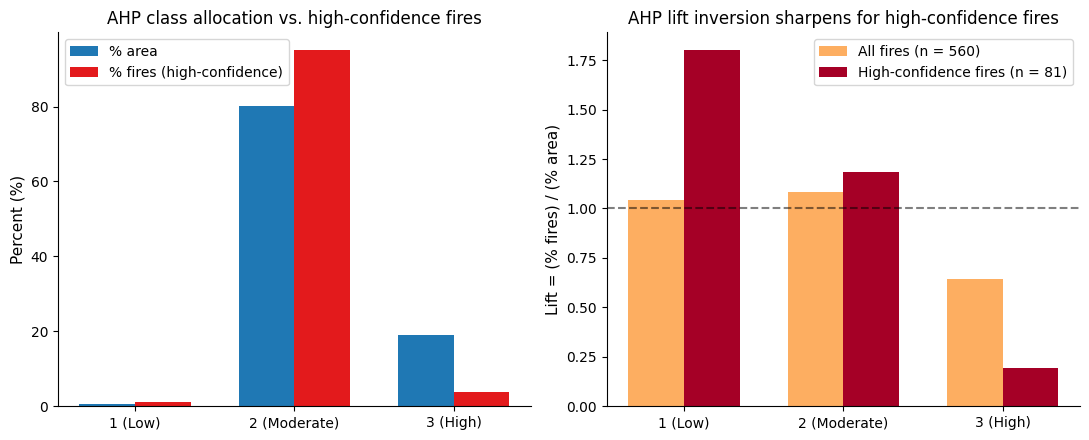

In [29]:

# ── Figure S5: HC subset comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
classes = ["1 (Low)", "2 (Moderate)", "3 (High)"]
x = np.arange(3); w = 0.35
ax.bar(x - w/2, [ahp_val["pct_area"][c] for c in (1,2,3)], w,
        label="% area", color="#1f78b4")
ax.bar(x + w/2, [hc_pct_fire[c] for c in (1,2,3)], w,
        label="% fires (high-confidence)", color="#e31a1c")
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel("Percent (%)")
ax.set_title("AHP class allocation vs. high-confidence fires")
ax.legend()

ax = axes[1]
ax.bar(x - w/2, [ahp_val["lift"][c] for c in (1,2,3)], w,
        label=f"All fires (n = {ahp_val['n_fires']})", color="#fdae61")
ax.bar(x + w/2, [hc_lift[c] for c in (1,2,3)], w,
        label=f"High-confidence fires (n = {len(hc_class)})", color="#a50026")
ax.axhline(1.0, color="black", linestyle="--", alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel("Lift = (% fires) / (% area)")
ax.set_title("AHP lift inversion sharpens for high-confidence fires")
ax.legend()
fig.savefig(os.path.join(OUT_DIR, "figures", "figS5_high_confidence.png"),
            dpi=200, bbox_inches="tight")
plt.tight_layout()
plt.show()



## 16. Moran's I on logistic regression residuals

The Moran's I test on the residuals of the baseline logistic regression
diagnoses whether residual spatial autocorrelation remains after fitting.
A non-significant result supports the claim that the predictors capture the
spatial structure adequately. The implementation uses a 10-nearest-neighbour
row-standardised weight matrix and 999 random permutations.


In [30]:

# ── Fit baseline logistic to obtain residuals ──────────────────────────────
X_d = sm.add_constant(X_base)
m_base = sm.Logit(y_base, X_d).fit(disp=0, maxiter=200)
mu = m_base.predict(X_d)
residuals = y_base - mu

xy = df_log_base[["x_utm", "y_utm"]].values
n  = len(residuals)
k  = 10

# 10-nearest-neighbour matrix (row-standardised binary weights)
ttree = cKDTree(xy)
neigh = ttree.query(xy, k=k+1)[1][:, 1:]   # drop self

z   = residuals - residuals.mean()
den = (z ** 2).sum()

def moran_I(z_):
    num = 0.0
    for i in range(n):
        num += (z_[i] * z_[neigh[i]]).sum() / k     # row-standardised w_ij = 1/k
    return num / den

I_obs = moran_I(z)
EI    = -1 / (n - 1)

# Permutation reference distribution
rng = np.random.default_rng(RANDOM_SEED)
perm_I = []
for _ in range(999):
    z_p = rng.permutation(z)
    perm_I.append(moran_I(z_p))
perm_I = np.array(perm_I)
p_two = (np.sum(np.abs(perm_I - EI) >= abs(I_obs - EI)) + 1) / (len(perm_I) + 1)

print(f"Moran's I (observed):     {I_obs:+.4f}")
print(f"Expected I (under null):  {EI:+.4f}")
print(f"Permutation mean:         {perm_I.mean():+.4f}")
print(f"Permutation std:           {perm_I.std(ddof=1):.4f}")
print(f"Two-sided p (999 perms):  {p_two:.4f}")


Moran's I (observed):     -0.0045
Expected I (under null):  -0.0003
Permutation mean:         +0.0000
Permutation std:           0.0077
Two-sided p (999 perms):  0.5690



## 17. AHP weight sensitivity (Table S4 and Figure S2)

This analysis reconstructs the AHP risk surface from the criterion rasters
under four weighting schemes — original, climate halved, climate zeroed, and
equal — and validates each against the fire records. The result is that the
inversion of fire density across AHP classes persists across all four
schemes; climate-criterion resolution is therefore a contributor to but not
the sole cause of the AHP failure.


In [31]:

# ── Reclassify each criterion to a 1..5 ordinal risk scale ─────────────────
def reclass_quintile(arr, low_is_high):
    """Reclassify a continuous raster into 1..5 ordinal risk classes by
    quintile breaks.  If low_is_high=True, the lowest values get the
    highest risk (e.g. NDVI, distance, humidity); otherwise the highest
    values get the highest risk (e.g. LST, slope)."""
    finite = np.isfinite(arr)
    out = np.full(arr.shape, np.nan, dtype=np.float32)
    if not finite.any(): return out
    qs = np.quantile(arr[finite], [0.2, 0.4, 0.6, 0.8])
    if low_is_high:
        out[finite & (arr <= qs[0])]                        = 5
        out[finite & (arr > qs[0]) & (arr <= qs[1])]        = 4
        out[finite & (arr > qs[1]) & (arr <= qs[2])]        = 3
        out[finite & (arr > qs[2]) & (arr <= qs[3])]        = 2
        out[finite & (arr > qs[3])]                          = 1
    else:
        out[finite & (arr <= qs[0])]                        = 1
        out[finite & (arr > qs[0]) & (arr <= qs[1])]        = 2
        out[finite & (arr > qs[1]) & (arr <= qs[2])]        = 3
        out[finite & (arr > qs[2]) & (arr <= qs[3])]        = 4
        out[finite & (arr > qs[3])]                          = 5
    return out

def aspect_to_risk(aspect_arr):
    """South-facing slopes get the highest risk (typical N-hemisphere convention)."""
    out = np.full(aspect_arr.shape, np.nan, dtype=np.float32)
    finite = np.isfinite(aspect_arr) & (aspect_arr >= 0)
    a = aspect_arr[finite]
    risk = np.ones_like(a)
    risk[(a >=  22.5) & (a <  67.5)] = 2
    risk[(a >=  67.5) & (a < 112.5)] = 3
    risk[(a >= 112.5) & (a < 157.5)] = 4
    risk[(a >= 157.5) & (a < 202.5)] = 5
    risk[(a >= 202.5) & (a < 247.5)] = 4
    risk[(a >= 247.5) & (a < 292.5)] = 3
    risk[(a >= 292.5) & (a < 337.5)] = 2
    out[finite] = risk
    return out

# Build risk grids on the AHP grid (250x349, 64 m).  We sample each
# criterion at the AHP cell centres using rasterio.sample.
H_ahp, W_ahp = ahp_arr.shape
ahp_xs = ahp_t[2] + (np.arange(W_ahp) + 0.5) * ahp_t[0]
ahp_ys = ahp_t[5] + (np.arange(H_ahp) + 0.5) * ahp_t[4]
xx_ahp, yy_ahp = np.meshgrid(ahp_xs, ahp_ys)
ahp_xs_flat = xx_ahp.flatten(); ahp_ys_flat = yy_ahp.flatten()

def risk_grid_from_layer(layer_key, low_is_high, special=None):
    """Sample the named criterion onto the AHP grid and reclassify."""
    arr_s = sample_raster(LAYER_PATHS[layer_key], ahp_xs_flat, ahp_ys_flat).reshape(H_ahp, W_ahp)
    if special == "aspect":
        return aspect_to_risk(arr_s)
    return reclass_quintile(arr_s, low_is_high=low_is_high)

risk_grids = {
    "NDVI":     risk_grid_from_layer("NDVI_2025",          True),
    "LST":      risk_grid_from_layer("LST_2025",           False),
    "Slope":    risk_grid_from_layer("Slope",              False),
    "Elev":     risk_grid_from_layer("Elev",               True),
    "Humidity": risk_grid_from_layer("Humidity_2025",      True),
    "Precip":   risk_grid_from_layer("Precipitation_2025", True),
    "Aspect":   risk_grid_from_layer("Aspect", False, special="aspect"),
    "D2Road":   risk_grid_from_layer("D2Road",             True),
    "D2Place":  risk_grid_from_layer("D2Place",            True),
    "D2Water":  risk_grid_from_layer("D2Water",            True),
}
print("Risk grids constructed.")


Risk grids constructed.


In [32]:

# ── Define and validate the four weight schemes ────────────────────────────
WEIGHTS_ORIG = {
    "Humidity": 30.86, "LST": 18.74, "NDVI": 11.83, "D2Road": 8.99,
    "Slope":     7.33, "D2Place": 5.50, "Aspect":  4.34, "Elev":   3.42,
    "Precip":    6.04, "D2Water": 2.95,
}
CLIMATE_KEYS = ["Humidity", "LST", "Precip"]
NONCLIM_KEYS = [k for k in WEIGHTS_ORIG if k not in CLIMATE_KEYS]

def renorm(d):
    s = sum(d.values())
    return {k: 100 * v / s for k, v in d.items()}

schemes = {
    "original":     WEIGHTS_ORIG.copy(),
    "climate_half": renorm({k: (v / 2 if k in CLIMATE_KEYS else v)
                              for k, v in WEIGHTS_ORIG.items()}),
    "climate_zero": renorm({k: WEIGHTS_ORIG[k] for k in NONCLIM_KEYS}),
    "equal":        {k: 10.0 for k in WEIGHTS_ORIG},
}

def reclass_3(values):
    """Reclassify the continuous risk surface into 3 management classes
    (Low, Moderate, High) using equal-interval breaks."""
    finite = np.isfinite(values)
    if not finite.any(): return values
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    breaks = np.linspace(vmin, vmax, 4)
    out = np.full_like(values, np.nan, dtype=np.float32)
    out[finite & (values  < breaks[1])]                            = 1
    out[finite & (values >= breaks[1]) & (values < breaks[2])]     = 2
    out[finite & (values >= breaks[2])]                             = 3
    return out

sens_results = []
for name, w in schemes.items():
    score = np.zeros((H_ahp, W_ahp), dtype=np.float32)
    wsum  = np.zeros((H_ahp, W_ahp), dtype=np.float32)
    for k, weight in w.items():
        g = risk_grids[k]
        valid = np.isfinite(g)
        score[valid] += g[valid] * (weight / 100.0)
        wsum[valid]  += (weight / 100.0)
    score = np.where(wsum > 0.95, score / np.maximum(wsum, 1e-6), np.nan)
    score = np.where(in_res, score, np.nan)
    risk3 = reclass_3(score)

    # Sample the reconstructed risk surface at fire points by direct array
    # indexing (the AHP grid uses integer pixel coordinates aligned with
    # the original AHP transform, so we can map UTM → row/col directly).
    cols_f = ((fire_xs - ahp_t[2]) / ahp_t[0]).astype(int)
    rows_f = ((fire_ys - ahp_t[5]) / ahp_t[4]).astype(int)
    valid_f = (cols_f >= 0) & (cols_f < W_ahp) & (rows_f >= 0) & (rows_f < H_ahp)
    fcl = np.full(len(fire_xs), np.nan)
    fcl[valid_f] = risk3[rows_f[valid_f], cols_f[valid_f]]

    res = validate_classes(risk3, fcl, in_res)
    sens_results.append({
        "Scheme": name,
        "Lift Low":  round(res["lift"][1], 2),
        "Lift Mod":  round(res["lift"][2], 2),
        "Lift High": round(res["lift"][3], 2),
        "AUC":       round(res["auc"], 3),
        "AUC CI":    f"[{res['auc_ci'][0]:.2f}, {res['auc_ci'][1]:.2f}]",
        "χ²":        round(res["chi2"], 2),
        "p":         round(res["chi2_p"], 4),
    })
    print(f"Scheme {name:14s}: lift = {res['lift'][1]:.2f}/{res['lift'][2]:.2f}/"
          f"{res['lift'][3]:.2f}  AUC = {res['auc']:.3f}")

table_s4 = pd.DataFrame(sens_results)
table_s4.to_csv(os.path.join(OUT_DIR, "tables", "tableS4_ahp_sensitivity.csv"),
                 index=False)
table_s4


Scheme original      : lift = 1.21/1.03/0.73  AUC = 0.459
Scheme climate_half  : lift = 1.27/1.07/0.57  AUC = 0.440
Scheme climate_zero  : lift = 1.26/1.05/0.56  AUC = 0.449
Scheme equal         : lift = 1.32/1.00/0.72  AUC = 0.454


,Scheme,Lift Low,Lift Mod,Lift High,AUC,AUC CI,χ²,p
0,original,1.21,1.03,0.73,0.459,"[0.43, 0.48]",14.57,0.0007
1,climate_half,1.27,1.07,0.57,0.440,"[0.41, 0.47]",25.49,0.0000
2,climate_zero,1.26,1.05,0.56,0.449,"[0.42, 0.48]",22.28,0.0000
3,equal,1.32,1.00,0.72,0.454,"[0.43, 0.48]",14.36,0.0008


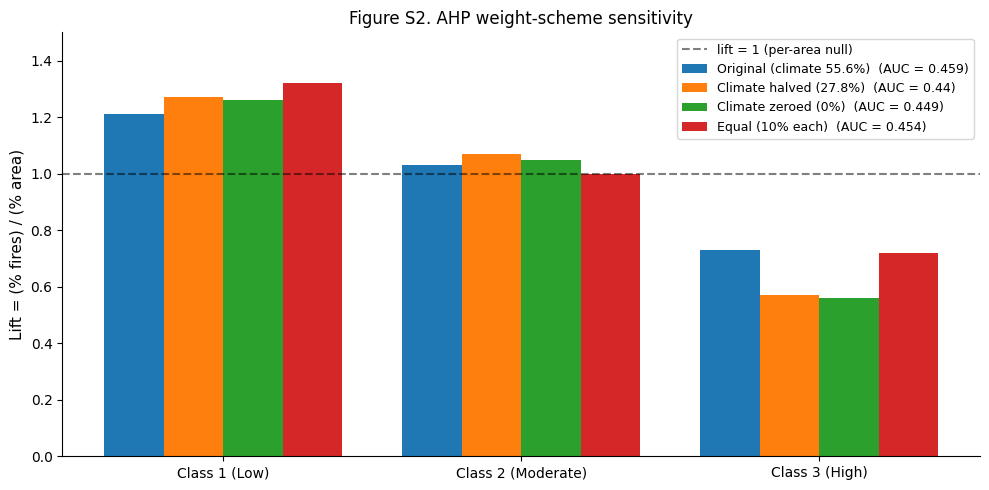

In [33]:

# ── Figure S2: AHP weight-sensitivity bars ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3); width = 0.2
labels = {"original":     "Original (climate 55.6%)",
           "climate_half": "Climate halved (27.8%)",
           "climate_zero": "Climate zeroed (0%)",
           "equal":        "Equal (10% each)"}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for i, (s, lbl) in enumerate(labels.items()):
    row = next(r for r in sens_results if r["Scheme"] == s)
    lifts = [row["Lift Low"], row["Lift Mod"], row["Lift High"]]
    ax.bar(x + (i - 1.5) * width, lifts, width,
            label=f"{lbl}  (AUC = {row['AUC']})", color=colors[i])
ax.axhline(1.0, color="black", linestyle="--", alpha=0.5,
            label="lift = 1 (per-area null)")
ax.set_xticks(x); ax.set_xticklabels(["Class 1 (Low)", "Class 2 (Moderate)", "Class 3 (High)"])
ax.set_ylabel("Lift = (% fires) / (% area)")
ax.set_title("Figure S2. AHP weight-scheme sensitivity")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 1.5)
fig.savefig(os.path.join(OUT_DIR, "figures", "figS2_ahp_sensitivity.png"),
            dpi=200, bbox_inches="tight")
plt.tight_layout()
plt.show()



## 18. Stakeholder questionnaire summaries (Figure 8)

The questionnaire is loaded and summarised by thematic block. Each item is
reported as a Yes-rate with Wilson 95% confidence intervals, following the
manuscript.


In [34]:

import re
qpath = os.path.join(DATA_ROOT, "Questionannire (Responses).xlsx")
q = pd.read_excel(qpath)
print(f"Questionnaire respondents: n = {len(q)}")
print(f"Columns: {len(q.columns)}")

def wilson_ci(x, n, alpha=0.05):
    """Wilson 95% CI for a binomial proportion."""
    if n == 0: return (0, 0)
    z = stats.norm.ppf(1 - alpha / 2)
    p = x / n
    den = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / den
    half = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / den
    return (centre - half, centre + half)

def summarise_block(df, prefix_or_keys, label):
    """Return a tidy DataFrame of Yes-rates with Wilson CIs for the items
    matching prefix_or_keys (a substring or a list of substrings)."""
    if isinstance(prefix_or_keys, str):
        cols = [c for c in df.columns if prefix_or_keys.lower() in str(c).lower()]
    else:
        cols = [c for c in df.columns
                 if any(k.lower() in str(c).lower() for k in prefix_or_keys)]
    rows = []
    for c in cols:
        # Extract item label: between brackets if present, otherwise full name
        m = re.search(r"\[(.*?)\]", str(c))
        item = m.group(1).strip() if m else str(c)
        vals = df[c].dropna().astype(str).str.strip().str.lower()
        total = len(vals)
        yes   = int((vals == "yes").sum())
        rate  = 100 * yes / total if total else 0
        lo, hi = wilson_ci(yes, total)
        rows.append({"category": label, "item": item, "n": total, "yes": yes,
                      "rate": rate, "lo": 100 * lo, "hi": 100 * hi})
    return pd.DataFrame(rows)

# Categories follow the seven thematic blocks in the manuscript
blocks = [
    ("(a) Causes of forest fires",
        ["causes of forest fire", "factors responsible for forest fire"]),
    ("(b) Causes of deforestation",        ["deforestation"]),
    ("(c) Beneficial roles of fire",       ["benefit", "advantageous", "positive"]),
    ("(d) Purposes of deliberate burning", ["deliberate", "purposeful", "intentional"]),
    ("(e) Ecological impacts",             ["ecological", "biodiversity", "habitat", "soil"]),
    ("(f) Socio-economic impacts",         ["socio-economic", "yield", "loss of livelihood",
                                            "destruction of property", "farmland"]),
    ("(g) Management challenges",          ["challenges of forest fire", "management"]),
]

q_summary = pd.concat([summarise_block(q, kws, lbl) for lbl, kws in blocks],
                      ignore_index=True)
q_summary.to_csv(os.path.join(OUT_DIR, "tables", "questionnaire_summary.csv"), index=False)
print(f"Items summarised: {len(q_summary)}")
q_summary.head(15)


Questionnaire respondents: n = 55
Columns: 47
Items summarised: 45


,category,item,n,yes,rate,lo,hi
0,(a) Causes of forest fires,Do you agree that there are factors responsibl...,55,54,98.181818,90.394224,99.678322
1,(a) Causes of forest fires,Agricultural Expansion,55,40,72.727273,59.767802,82.719248
2,(a) Causes of forest fires,Hunting Practices,55,45,81.818182,69.669540,89.812330
3,(a) Causes of forest fires,Silvicultural Management,55,26,47.272727,34.693098,60.208456
4,(a) Causes of forest fires,Logging,55,34,61.818182,48.609220,73.484046
5,(a) Causes of forest fires,Charcoal Production,55,34,61.818182,48.609220,73.484046
6,(a) Causes of forest fires,Climate (Weather),55,38,69.090909,55.971410,79.717712
7,(a) Causes of forest fires,Accident/Negligence,55,32,58.181818,45.033104,70.262234
8,(a) Causes of forest fires,Natural Causes,55,33,60.000000,46.812799,71.881503
9,(b) Causes of deforestation,Agricultural Development,55,45,81.818182,69.669540,89.812330


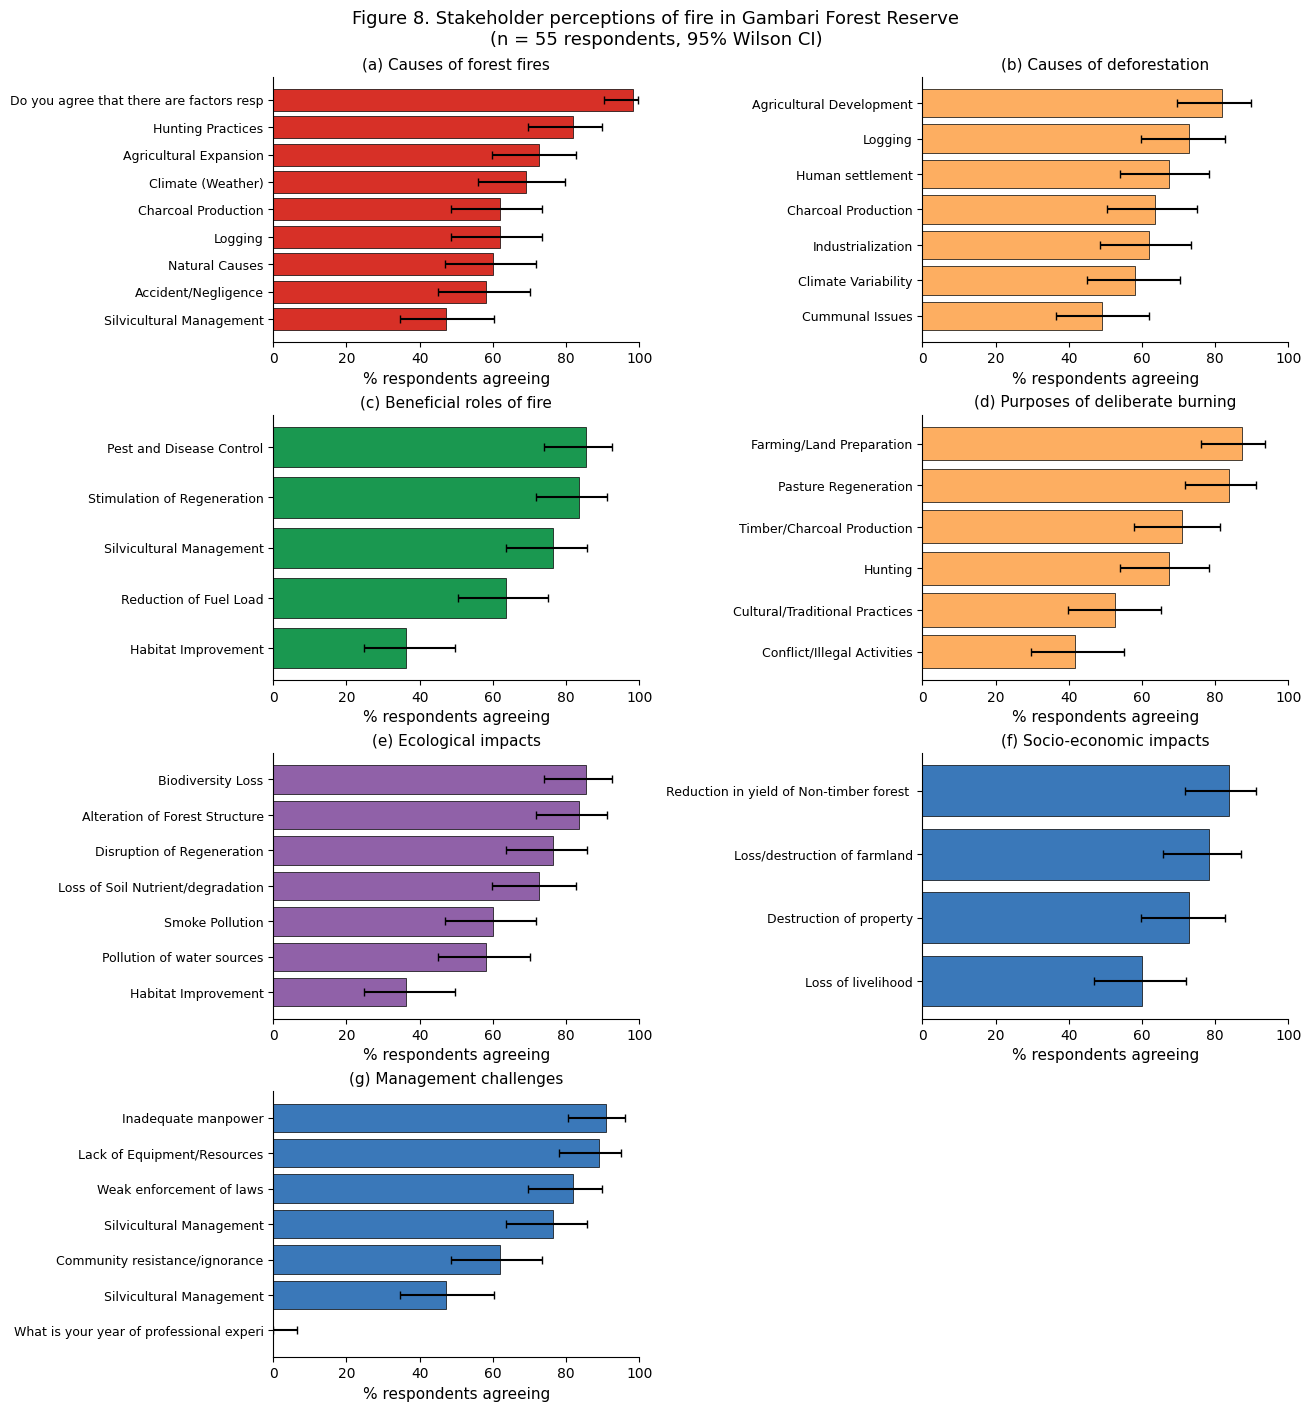

In [35]:

# ── Figure 8: stakeholder-perception bar charts ────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(13, 14), constrained_layout=True)
axes = axes.flatten()
panel_colors = ["#d73027", "#fdae61", "#1a9850", "#fdae61", "#9061a8", "#3a78b9", "#3a78b9"]

for idx, (label, _) in enumerate(blocks):
    sub = q_summary[q_summary.category == label].sort_values("rate", ascending=True)
    if sub.empty:
        axes[idx].axis("off"); continue
    ax = axes[idx]
    y_pos = np.arange(len(sub))
    ax.barh(y_pos, sub.rate, xerr=[sub.rate - sub.lo, sub.hi - sub.rate],
            color=panel_colors[idx % len(panel_colors)],
            edgecolor="black", linewidth=0.5, capsize=3)
    ax.set_yticks(y_pos); ax.set_yticklabels(sub["item"].str[:40], fontsize=9)
    ax.set_xlim(0, 100); ax.set_xlabel("% respondents agreeing")
    ax.set_title(label, fontsize=11)

# Hide the unused 8th subplot
if len(blocks) < len(axes):
    axes[-1].axis("off")

fig.suptitle("Figure 8. Stakeholder perceptions of fire in Gambari Forest Reserve\n"
             f"(n = {len(q)} respondents, 95% Wilson CI)", fontsize=13)
fig.savefig(os.path.join(OUT_DIR, "figures", "fig8_stakeholders.png"),
            dpi=200, bbox_inches="tight")
plt.show()



## 19. Final summary

All figures and tables have been saved to `OUT_DIR`. The cell below writes a
single JSON file summarising the headline statistics, useful for cross-
referencing during writing or for downstream programmatic checks.


In [36]:

summary = {
    "fire_regime": {
        "n":                int(len(fires_utm)),
        "annual_mean":      float(annual.mean()),
        "annual_sd":        float(annual.std()),
        "trend_slope":      float(slope),
        "trend_p_lin":      float(p_lin),
        "mann_kendall":     mk,
        "dry_season_pct":   float(100 * n_dry / len(fires_utm)),
        "frp_cat1":         int((frp < 100).sum()),
        "frp_max":          float(frp.max()),
        "aqua_count":       int(sat_counts.get("Aqua", 0)),
        "terra_count":      int(sat_counts.get("Terra", 0)),
        "clark_evans_R_reserve": float(ce_reserve[2]),
        "clark_evans_R_bbox":    float(ce_bbox[2]),
        "reserve_area_ha":  float(reserve_area_m2 / 10000),
    },
    "ahp_validation": {
        "auc":       float(ahp_val["auc"]),
        "auc_ci":    [float(ahp_val["auc_ci"][0]), float(ahp_val["auc_ci"][1])],
        "lift_low":  float(ahp_val["lift"][1]),
        "lift_mod":  float(ahp_val["lift"][2]),
        "lift_high": float(ahp_val["lift"][3]),
        "chi2":      float(ahp_val["chi2"]),
        "chi2_p":    float(ahp_val["chi2_p"]),
    },
    "data_driven_models": [
        {"name": r["Model"],
         "in_sample": r["In-sample AUC"],
         "rand_cv":   r["Random CV AUC"],
         "spat_cv":   r["Spatial-block CV AUC"]}
        for r in table6_rows
    ],
    "morans_I": {
        "I":      float(I_obs),
        "EI":     float(EI),
        "p":      float(p_two),
    },
    "high_confidence": {
        "n":           int(len(fires_hc)),
        "auc_rand_cv": float(rmean_hc),
        "lift_high":   float(hc_lift[3]),
    },
    "ahp_sensitivity": sens_results,
}
with open(os.path.join(OUT_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print("All outputs saved to OUT_DIR =", OUT_DIR)
print("Summary JSON written: summary.json")


All outputs saved to OUT_DIR = /content/output
Summary JSON written: summary.json
